# DS 5110 EDA — DIME + FEC Party Classification

This notebook is an initial EDA I did; I tried using a year's transaction data from itemized contribution records, but even a year's worth was so large that it took a long time to process and exceeded 50GB. So this version avoids the huge DIME itemized transaction files and removes the DIME Donors/PACs aggregate table, since that table cannot be reliably linked back to recipients/candidates without itemized contribution links.

What I used for a POC(proof of concept):

1. Stanford DIME **Recipients/Candidates** aggregate data
2. Federal Election Commission **Candidate Summary**
3. FEC **Candidate Master**
4. FEC **Candidate-Committee Linkage**
5. FEC **Committee Master / Committee Summary**

The FEC features are joined directly when a compatible FEC candidate ID exists in DIME. If no compatible ID exists, the notebook adds valid **year + state** FEC context features without using the target party as a join key.

This notebook includes:

- Data import and preprocessing
- DIME + FEC feature engineering
- Missing-value handling and compact Parquet caching
- Automatic constant/all-zero column removal
- Train/test split
- EDA with many tables and graphs
- Three Spark ML models
- K-fold cross-validation and hyperparameter tuning
- Model evaluation with accuracy, precision, recall, F1, confusion matrices, and one-vs-rest AUROC
- Random Forest feature importance and Logistic Regression coefficient importance
- Champion model selection and hyperparameter sensitivity analysis

In [1]:
import os
import re
import gzip
import zipfile
import shutil
import urllib.request
from pathlib import Path
from typing import Optional, Sequence, List, Dict

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.storagelevel import StorageLevel

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.functions import vector_to_array

DATA_DIR = Path("./data/dime_fec_final_project")
DATA_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Multiple years, not just 2024.
START_YEAR = 2012
END_YEAR = 2016
YEAR_LABEL = f"{START_YEAR}_{END_YEAR}"

# Hard limit requested by you.
MAX_FINAL_TABLE_GB = 40.0

# Download missing files from Stanford if needed.
DOWNLOAD_DATA_IF_MISSING = True

# If .csv.gz exists but .csv does not, decompress once.
# Uncompressed CSV generally lets Spark split the input better than one large .gz file.
DECOMPRESS_GZ_TO_CSV = True

# Main modeling controls
ADD_DONOR_PAC_CONTEXT = True

# Add FEC candidate/committee context instead of DIME contribDB and donor/PAC aggregate context.
ADD_FEC_CONTEXT = True
FEC_CYCLES = [2012, 2014, 2016]
DOWNLOAD_FEC_IF_MISSING = True
READ_FEC_FEATURES_IF_EXISTS = True
WRITE_FEC_FEATURES_PARQUET = True

# Add Itemized contribution donor-level model config 
CONTRIB_MODEL_CYCLES = [2012]
CONTRIB_SAMPLE_FRACTION = 0.10 
CONTRIB_MAX_TABLE_GB = 5.0 

CONTRIB_MODEL_PARQUET = PROCESSED_DIR / (
    f"contrib_donor_party_model_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
)
READ_CONTRIB_MODEL_IF_EXISTS = True
WRITE_CONTRIB_MODEL_PARQUET = True
FORCE_REBUILD_CONTRIB_MODEL = False

OCCUPATION_TOP_N = 250

# Reuse compact model parquet once built.
READ_FINAL_MODEL_IF_EXISTS = True
WRITE_FINAL_MODEL_PARQUET = True
# Set True after changing donor/PAC context settings so you do not read an old Parquet cache.
FORCE_REBUILD_FINAL_MODEL = False

# Keep expensive debug actions controlled.
SHOW_DEBUG = True
RUN_EXPENSIVE_COUNTS = True
MAKE_GRAPHS = True

# Modeling controls
USE_RECIPIENT_CFSCORE_FEATURE = False

# Remove useless numeric columns that are constant/all-zero, such as vote pct fields when unavailable.
DROP_CONSTANT_ZERO_COLUMNS = True
TEST_FRACTION = 0.2
RANDOM_SEED = 42

# Cross-validation/hyperparameter tuning controls.
FAST_CV = True
NUM_FOLDS = 3
MAX_TRAIN_ROWS_FOR_TUNING = None 

# Spark partition controls
NUM_CORES = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 8))
SHUFFLE_PARTITIONS = max(32, NUM_CORES * 4)
MODEL_PARTITIONS = max(16, NUM_CORES * 2)

print("Years:", START_YEAR, "to", END_YEAR)
print("NUM_CORES:", NUM_CORES)
print("SHUFFLE_PARTITIONS:", SHUFFLE_PARTITIONS)
print("MODEL_PARTITIONS:", MODEL_PARTITIONS)
from pyspark.sql.types import DoubleType, IntegerType, StringType, StructType, StructField, LongType


Years: 2012 to 2016
NUM_CORES: 2
SHUFFLE_PARTITIONS: 32
MODEL_PARTITIONS: 16


In [2]:
spark = (
    SparkSession.builder
    .appName("DIME_Aggregate_PLUS_Fast_Party_Modeling")
    .master(f"local[{NUM_CORES}]")
    .config("spark.sql.shuffle.partitions", str(SHUFFLE_PARTITIONS))
    .config("spark.default.parallelism", str(SHUFFLE_PARTITIONS))
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.skewJoin.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)
print("Shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/26 13:51:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark master: local[2]
Default parallelism: 32
Shuffle partitions: 32


# File paths and download helpers

In [3]:
# Stanford DIME aggregate links
RECIPIENTS_URL = "https://www.dropbox.com/scl/fi/bcpmxvxwc7iwmqvchm2sp/dime_recipients_1979_2024.csv.gz?dl=1&rlkey=4ii8765xw8y2svlzcbxzfvnbh"

RECIPIENTS_GZ = DATA_DIR / "dime_recipients_1979_2024.csv.gz"
RECIPIENTS_CSV = DATA_DIR / "dime_recipients_1979_2024.csv"

contrib_urls = {
    2012: "https://www.dropbox.com/scl/fi/dx8tafolqtrgp2dbn4fg6/contribDB_2012.csv.gz?rlkey=sslqxjhubk9745pfb0shcq5k4&dl=1",
    2014: "https://www.dropbox.com/scl/fi/g0omy5h86mddmwcai43fk/contribDB_2014.csv.gz?rlkey=btee8x45og1vphwpvnfe9qttg&dl=1",
    2016: "https://www.dropbox.com/scl/fi/qg5vezrx876cmu7u9hehr/contribDB_2016.csv.gz?rlkey=dsl4htd0ovr8hyn7xwctel0a0&dl=1",
    2018: "https://www.dropbox.com/scl/fi/sk2fbjbrq7hgdqfnern2g/contribDB_2018.csv.gz?rlkey=qsk4o1wjc8p1bwozuuk4bwq01&dl=1",
    2020: "https://www.dropbox.com/scl/fi/rnmdp79g0ewbf9j68tz1s/contribDB_2020.csv.gz?rlkey=v3y2xuvnmqueaiwkllls81mul&dl=1",
    2022: "https://www.dropbox.com/scl/fi/odu6raws98gu1xdmx0ql3/contribDB_2022.csv.gz?rlkey=bvrmhaftpp2sa6tv3lu120v44&dl=1",
    2024: "https://www.dropbox.com/scl/fi/p3adbtd50033ilt5ir3n2/contribDB_2024.csv.gz?rlkey=gt8l9j6xoi6h07syr94f33oyv&dl=1"
}

# CONTRIB data folder
CONTRIB_DIR = DATA_DIR / "contrib"
CONTRIB_DIR.mkdir(parents=True, exist_ok=True)

# FEC data folder
FEC_DIR = DATA_DIR / "fec"
FEC_DIR.mkdir(parents=True, exist_ok=True)

FEC_FEATURES_PARQUET = PROCESSED_DIR / f"fec_candidate_committee_features_{min(FEC_CYCLES)}_{max(FEC_CYCLES)}_parquet"

FINAL_MODEL_PARQUET = PROCESSED_DIR / f"dime_no_dimeplus_party_model_{YEAR_LABEL}_parquet"

def path_size_gb(path: Path) -> float:
    if not path.exists():
        return 0.0
    if path.is_file():
        return path.stat().st_size / 1024**3
    total = 0
    for p in path.rglob("*"):
        if p.is_file():
            total += p.stat().st_size
    return total / 1024**3

def download_if_missing(url: str, out_path: Path, enabled: bool = True) -> None:
    if out_path.exists() and out_path.stat().st_size > 0:
        print("Already exists:", out_path, "GB:", round(path_size_gb(out_path), 3))
        return
    if not enabled:
        print("Download disabled; missing:", out_path)
        return

    print("Downloading:", out_path)
    print("From:", url)
    urllib.request.urlretrieve(url, out_path)
    print("Downloaded:", out_path, "GB:", round(path_size_gb(out_path), 3))

def decompress_gz_if_needed(gz_path: Path, csv_path: Path) -> Path:
    if csv_path.exists() and csv_path.stat().st_size > 0:
        print("Using existing CSV:", csv_path, "GB:", round(path_size_gb(csv_path), 3))
        return csv_path

    if not gz_path.exists():
        raise FileNotFoundError(f"Missing both CSV and GZ: {csv_path} / {gz_path}")

    if not DECOMPRESS_GZ_TO_CSV:
        print("Using GZ directly:", gz_path)
        return gz_path

    free_gb = shutil.disk_usage(str(DATA_DIR)).free / 1024**3
    print("Free disk GB:", round(free_gb, 2))
    print("Decompressing:", gz_path, "->", csv_path)
    with gzip.open(gz_path, "rb") as f_in:
        with open(csv_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("Created:", csv_path, "GB:", round(path_size_gb(csv_path), 3))
    return csv_path


def unzip_if_needed(zip_path: Path, output_dir: Path) -> Optional[Path]:
    if not zip_path.exists():
        print("ZIP missing:", zip_path)
        return None

    output_dir.mkdir(parents=True, exist_ok=True)

    existing = list(output_dir.glob("*.txt")) + list(output_dir.glob("*.csv"))
    if existing:
        print("Using existing extracted file:", existing[0])
        return existing[0]

    print("Unzipping:", zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        names = [n for n in z.namelist() if n.lower().endswith((".txt", ".csv"))]
        if not names:
            print("No txt/csv found in:", zip_path)
            return None
        z.extract(names[0], output_dir)
        return output_dir / names[0]

def fec_cycle_suffix(cycle: int) -> str:
    return str(cycle)[-2:]

def fec_candidate_summary_url(cycle: int) -> str:
    return f"https://www.fec.gov/files/bulk-downloads/{cycle}/candidate_summary_{cycle}.csv"

def fec_committee_summary_url(cycle: int) -> str:
    return f"https://www.fec.gov/files/bulk-downloads/{cycle}/committee_summary_{cycle}.csv"

def fec_candidate_master_url(cycle: int) -> str:
    return f"https://www.fec.gov/files/bulk-downloads/{cycle}/cn{fec_cycle_suffix(cycle)}.zip"

def fec_committee_master_url(cycle: int) -> str:
    return f"https://www.fec.gov/files/bulk-downloads/{cycle}/cm{fec_cycle_suffix(cycle)}.zip"

def fec_candidate_committee_linkage_url(cycle: int) -> str:
    return f"https://www.fec.gov/files/bulk-downloads/{cycle}/ccl{fec_cycle_suffix(cycle)}.zip"

def get_fec_file_paths(cycle: int) -> dict:
    cycle_dir = FEC_DIR / str(cycle)
    cycle_dir.mkdir(parents=True, exist_ok=True)

    paths = {
        "candidate_summary": cycle_dir / f"candidate_summary_{cycle}.csv",
        "committee_summary": cycle_dir / f"committee_summary_{cycle}.csv",
        "candidate_master_zip": cycle_dir / f"cn{fec_cycle_suffix(cycle)}.zip",
        "committee_master_zip": cycle_dir / f"cm{fec_cycle_suffix(cycle)}.zip",
        "candidate_committee_linkage_zip": cycle_dir / f"ccl{fec_cycle_suffix(cycle)}.zip",
        "candidate_master_dir": cycle_dir / "candidate_master",
        "committee_master_dir": cycle_dir / "committee_master",
        "candidate_committee_linkage_dir": cycle_dir / "candidate_committee_linkage",
    }
    return paths

def download_fec_cycle_if_missing(cycle: int):
    paths = get_fec_file_paths(cycle)

    download_if_missing(fec_candidate_summary_url(cycle), paths["candidate_summary"], DOWNLOAD_FEC_IF_MISSING)
    download_if_missing(fec_committee_summary_url(cycle), paths["committee_summary"], DOWNLOAD_FEC_IF_MISSING)
    download_if_missing(fec_candidate_master_url(cycle), paths["candidate_master_zip"], DOWNLOAD_FEC_IF_MISSING)
    download_if_missing(fec_committee_master_url(cycle), paths["committee_master_zip"], DOWNLOAD_FEC_IF_MISSING)
    download_if_missing(fec_candidate_committee_linkage_url(cycle), paths["candidate_committee_linkage_zip"], DOWNLOAD_FEC_IF_MISSING)

    paths["candidate_master"] = unzip_if_needed(paths["candidate_master_zip"], paths["candidate_master_dir"])
    paths["committee_master"] = unzip_if_needed(paths["committee_master_zip"], paths["committee_master_dir"])
    paths["candidate_committee_linkage"] = unzip_if_needed(paths["candidate_committee_linkage_zip"], paths["candidate_committee_linkage_dir"])

    return paths

if not RECIPIENTS_CSV.exists() and not RECIPIENTS_GZ.exists():
    download_if_missing(RECIPIENTS_URL, RECIPIENTS_GZ, DOWNLOAD_DATA_IF_MISSING)


RECIPIENTS_INPUT = decompress_gz_if_needed(RECIPIENTS_GZ, RECIPIENTS_CSV)

CONTRIBUTORS_INPUT = None

FEC_INPUTS = {}
if ADD_FEC_CONTEXT:
    for cyc in FEC_CYCLES:
        FEC_INPUTS[int(cyc)] = download_fec_cycle_if_missing(int(cyc))

# Download/decompress the itemized cycles needed for the donor-level model.
# (Independent of ADD_DONOR_PAC_CONTEXT, which drives the older aggregate-only path.)
CONTRIB_MODEL_INPUTS = {}
for cyc in CONTRIB_MODEL_CYCLES:
    gz_path = CONTRIB_DIR / f"contribDB_{cyc}.csv.gz"
    csv_path = CONTRIB_DIR / f"contribDB_{cyc}.csv"
    if not csv_path.exists() and not gz_path.exists():
        download_if_missing(contrib_urls[cyc], gz_path, DOWNLOAD_DATA_IF_MISSING)
    CONTRIB_MODEL_INPUTS[cyc] = decompress_gz_if_needed(gz_path, csv_path)

print("Contrib model inputs:", CONTRIB_MODEL_INPUTS)

print("Recipients input:", RECIPIENTS_INPUT)
print("Contributors/Donor-PAC input: disabled")
print("FEC inputs:", FEC_INPUTS)
print("DIME+ contribDB and donor/PAC aggregate data are disabled in this notebook.")

Using existing CSV: data/dime_fec_final_project/dime_recipients_1979_2024.csv GB: 0.14
Already exists: data/dime_fec_final_project/fec/2012/candidate_summary_2012.csv GB: 0.001
Already exists: data/dime_fec_final_project/fec/2012/committee_summary_2012.csv GB: 0.006
Already exists: data/dime_fec_final_project/fec/2012/cn12.zip GB: 0.0
Already exists: data/dime_fec_final_project/fec/2012/cm12.zip GB: 0.001
Already exists: data/dime_fec_final_project/fec/2012/ccl12.zip GB: 0.0
Using existing extracted file: data/dime_fec_final_project/fec/2012/candidate_master/cn.txt
Using existing extracted file: data/dime_fec_final_project/fec/2012/committee_master/cm.txt
Using existing extracted file: data/dime_fec_final_project/fec/2012/candidate_committee_linkage/ccl.txt
Already exists: data/dime_fec_final_project/fec/2014/candidate_summary_2014.csv GB: 0.001
Already exists: data/dime_fec_final_project/fec/2014/committee_summary_2014.csv GB: 0.005
Already exists: data/dime_fec_final_project/fec/2014

# Robust utility functions

In [4]:
def safe_name(name: str) -> str:
    name = str(name).strip().lower()
    name = re.sub(r"[^0-9a-zA-Z]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    if not name:
        name = "col"
    if re.match(r"^\d", name):
        name = "c_" + name
    return name


def dedupe_names(names: Sequence[str]) -> List[str]:
    seen = {}
    out = []
    for n in names:
        base = safe_name(n)
        if base not in seen:
            seen[base] = 0
            out.append(base)
        else:
            seen[base] += 1
            out.append(f"{base}_{seen[base]}")
    return out


def qcol(name: str) -> str:
    return "`" + str(name).replace("`", "``") + "`"


def try_int_col(col_name: str):
    return F.expr(f"try_cast(nullif(trim(cast({qcol(col_name)} as string)), '') as int)")


def try_double_expr(expr_sql: str):
    return F.expr(f"try_cast({expr_sql} as double)")


def clean_double_col(col_name: str):
    return F.expr(
        f"try_cast(nullif(trim(regexp_replace(cast({qcol(col_name)} as string), '[$,]', '')), '') as double)"
    )


def read_csv_strings(path: Path) -> DataFrame:
    df = (
        spark.read
        .option("header", True)
        .option("inferSchema", False)
        .option("multiLine", False)
        .option("mode", "PERMISSIVE")
        .option("quote", '"')
        .option("escape", '"')
        .option("columnNameOfCorruptRecord", "_corrupt_record")
        .csv(str(path))
    )
    df = df.toDF(*dedupe_names(df.columns))
    return df


def first_present(df: DataFrame, candidates: Sequence[str]) -> Optional[str]:
    cols = set(df.columns)
    for c in candidates:
        c_safe = safe_name(c)
        if c_safe in cols:
            return c_safe
    return None


def first_present_contains(df: DataFrame, required_terms: Sequence[str], forbidden_terms: Sequence[str] = ()) -> Optional[str]:
    required_terms = [safe_name(t) for t in required_terms]
    forbidden_terms = [safe_name(t) for t in forbidden_terms]
    for c in df.columns:
        if all(t in c for t in required_terms) and not any(t in c for t in forbidden_terms):
            return c
    return None


def party_group_expr(c):
    x = F.upper(F.trim(c.cast("string")))
    return (
        F.when(x.isin("100", "D", "DEM", "DEMOCRAT", "DEMOCRATIC", "DEMOCRATIC_FARMER_LABOR", "DFL"), "DEMOCRAT")
         .when(x.isin("200", "R", "REP", "REPUBLICAN", "GOP"), "REPUBLICAN")
         .when(x.isNull() | (x == ""), None)
         .otherwise("OTHER")
    )


def ideology_group_expr(c):
    # c should usually already be numeric, but use cast safely after earlier clean_double_col.
    x = c.cast("double")
    return (
        F.when(x <= -0.25, "LEFT_LEANING")
         .when(x >= 0.25, "RIGHT_LEANING")
         .when(x.isNull(), None)
         .otherwise("MODERATE")
    )


def type_group_expr(c):
    x = F.upper(F.trim(c.cast("string")))
    return (
        F.when(x.isin("CAND", "CANDIDATE"), "CANDIDATE")
         .when(x.isin("COMM", "COMMITTEE", "PAC"), "COMMITTEE_OR_PAC")
         .when(x.isin("I", "IND", "INDIVIDUAL"), "INDIVIDUAL")
         .when(x.isNull() | (x == ""), "MISSING")
         .otherwise(x)
    )


def clean_cat(c):
    return F.coalesce(F.upper(F.trim(c.cast("string"))), F.lit("MISSING"))


def show_df(df: DataFrame, n: int = 20, truncate: bool = False) -> None:
    df.show(n, truncate=truncate)


def safe_ratio(num_col, den_col):
    return F.when(F.col(den_col) > 0, F.col(num_col) / F.col(den_col)).otherwise(F.lit(0.0))

# Raw data size summary

In [5]:
raw_size_rows = []
raw_size_rows.append(("dime_recipients_candidates", str(RECIPIENTS_INPUT), path_size_gb(Path(RECIPIENTS_INPUT))))

if ADD_DONOR_PAC_CONTEXT:
    for cyc, path in CONTRIB_MODEL_INPUTS.items():
        raw_size_rows.append((f'{cyc} contributions',str(path), path_size_gb(Path(path))))
    

if ADD_FEC_CONTEXT:
    for cyc, paths in FEC_INPUTS.items():
        for key, p in paths.items():
            if isinstance(p, Path) and p.exists() and p.is_file():
                raw_size_rows.append((f"fec_{key}_{cyc}", str(p), path_size_gb(p)))

raw_size_df = spark.createDataFrame(raw_size_rows, ["source", "path", "size_gb"])
show_df(raw_size_df.orderBy(F.desc("size_gb")), 100, truncate=False)

print("Approximate raw input size GB:", round(sum(r[2] for r in raw_size_rows), 3))

[Stage 0:================================================>        (27 + 2) / 32]

+----------------------------------------+------------------------------------------------------------------------+---------------------+
|source                                  |path                                                                    |size_gb              |
+----------------------------------------+------------------------------------------------------------------------+---------------------+
|2012 contributions                      |data/dime_fec_final_project/contrib/contribDB_2012.csv                  |12.513574211858213   |
|dime_recipients_candidates              |data/dime_fec_final_project/dime_recipients_1979_2024.csv               |0.1402341015636921   |
|fec_committee_summary_2016              |data/dime_fec_final_project/fec/2016/committee_summary_2016.csv         |0.0057824403047561646|
|fec_committee_summary_2012              |data/dime_fec_final_project/fec/2012/committee_summary_2012.csv         |0.005661504343152046 |
|fec_committee_summary_2014       

# DataFrame cleanup helpers

In [6]:
def unique_column_names(cols):
    """Return unique column names by suffixing duplicates."""
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}_dup{seen[c]}")
    return out

def make_columns_unique(df: DataFrame) -> DataFrame:
    """Spark can hold duplicate names after joins; Parquet writes cannot."""
    new_cols = unique_column_names(df.columns)
    if new_cols != df.columns:
        print("Duplicate column names detected and renamed.")
        return df.toDF(*new_cols)
    return df

def drop_uninformative_numeric_columns(
    df: DataFrame,
    protected_cols=None,
    max_cols_per_batch: int = 40,
):
    """
    Drops numeric columns that are all-null, constant, or all-zero.
    Protected columns such as identifiers, target, and categorical columns are never dropped.
    """
    if protected_cols is None:
        protected_cols = set()
    protected_cols = set(protected_cols)

    numeric_type_prefixes = ("double", "float", "int", "bigint", "long", "smallint", "tinyint", "decimal")
    numeric_cols = []
    for name, dtype in df.dtypes:
        if name in protected_cols:
            continue
        dtype_lower = dtype.lower()
        if any(dtype_lower.startswith(prefix) for prefix in numeric_type_prefixes):
            numeric_cols.append(name)

    audit_schema = StructType([
        StructField("column", StringType(), True),
        StructField("min", DoubleType(), True),
        StructField("max", DoubleType(), True),
        StructField("non_null_count", LongType(), True),
        StructField("approx_distinct", LongType(), True),
        StructField("drop_reason", StringType(), True),
    ])

    if not numeric_cols:
        empty = spark.createDataFrame([], audit_schema)
        return df, empty

    rows = []
    for start in range(0, len(numeric_cols), max_cols_per_batch):
        batch_cols = numeric_cols[start:start + max_cols_per_batch]
        exprs = []
        for c in batch_cols:
            exprs.extend([
                F.min(F.col(c)).alias(f"{c}__min"),
                F.max(F.col(c)).alias(f"{c}__max"),
                F.count(F.col(c)).alias(f"{c}__non_null"),
                F.approx_count_distinct(F.col(c)).alias(f"{c}__distinct"),
            ])

        stats = df.agg(*exprs).collect()[0].asDict()

        for c in batch_cols:
            min_v = stats.get(f"{c}__min")
            max_v = stats.get(f"{c}__max")
            non_null = stats.get(f"{c}__non_null") or 0
            approx_distinct = stats.get(f"{c}__distinct") or 0

            drop_reason = None
            if non_null == 0:
                drop_reason = "all_null"
            elif approx_distinct <= 1 and min_v == 0 and max_v == 0:
                drop_reason = "constant_all_zero"
            elif approx_distinct <= 1:
                drop_reason = "constant"

            rows.append((
                c,
                float(min_v) if min_v is not None else None,
                float(max_v) if max_v is not None else None,
                int(non_null),
                int(approx_distinct),
                drop_reason,
            ))

    audit_df = spark.createDataFrame(rows, audit_schema)

    drop_cols = [r["column"] for r in audit_df.filter(F.col("drop_reason").isNotNull()).collect()]
    if drop_cols:
        print("Dropping uninformative numeric columns:")
        for c in drop_cols:
            print("  -", c)
        df = df.drop(*drop_cols)
    else:
        print("No uninformative numeric columns detected.")

    return df, audit_df

def parquet_has_data(path: Path) -> bool:
    if not path.exists():
        return False
    if (path / "_SUCCESS").exists():
        return True
    return any(path.rglob("*.parquet"))

# Helpers for creating occupation categories

def clean_free_text(c):
    x = F.upper(F.trim(c.cast("string")))
    x = F.regexp_replace(x, r"[^A-Z0-9 ]", " ")
    x = F.regexp_replace(x, r"\s+", " ")
    x = F.trim(x)
    return F.when(
        x.isNull() | (x == "") | x.isin("NA", "N A", "NONE", "NOT EMPLOYED", "UNEMPLOYED"),
        "UNKNOWN"
    ).otherwise(x)

def top_n_category_values(fit_df: DataFrame, col_name: str, n: int) -> list:
    rows = (
        fit_df.groupBy(col_name)
        .count()
        .orderBy(F.desc("count"))
        .limit(n)
        .select(col_name)
        .collect()
    )
    return [r[col_name] for r in rows]

def apply_category_bucket(df, col_name, keep_values, out_col, other_label="OTHER"):
    return df.withColumn(
        out_col,
        F.when(F.col(col_name).isin(keep_values), F.col(col_name)).otherwise(F.lit(other_label))
    )

def apply_synonym_map(c, synonym_map: dict):
    mapping_expr = F.create_map([F.lit(x) for pair in synonym_map.items() for x in pair])
    return F.coalesce(mapping_expr.getItem(c), c)

def word_boundary_contains(text_col, phrase_col):
    padded_text = F.concat(F.lit(" "), text_col, F.lit(" "))
    padded_phrase = F.concat(F.lit(" "), phrase_col, F.lit(" "))
    return padded_text.contains(padded_phrase)

def build_fuzzy_category_map(
    fit_df, col_name, canonical_labels, max_norm_distance=0.2, min_len=3, contains_exclude=None,
) -> DataFrame:
    contains_exclude = contains_exclude or set()
    canonical_col = f"{col_name}_canonical"

    distinct_vals = (
        fit_df.select(col_name).distinct()
        .filter(F.col(col_name).isNotNull() & (F.length(col_name) >= min_len))
        .filter(~F.col(col_name).isin(canonical_labels))
    )
    canonical_df = spark.createDataFrame([(c,) for c in canonical_labels], [canonical_col])

    scored = (
        distinct_vals.crossJoin(F.broadcast(canonical_df))
        .withColumn("edit_dist", F.levenshtein(F.col(col_name), F.col(canonical_col)))
        .withColumn("max_len", F.greatest(F.length(col_name), F.length(canonical_col)))
        .withColumn("norm_dist", F.col("edit_dist") / F.col("max_len"))
        .withColumn(
            "raw_contains_match",
            # Whole-word/phrase match only -- fixes false positives like "COORDINATOR" matching "COO".
            word_boundary_contains(F.col(col_name), F.col(canonical_col))
            | word_boundary_contains(F.col(canonical_col), F.col(col_name))
        )
        .withColumn(
            "contains_match",
            F.col("raw_contains_match") & ~F.col(canonical_col).isin(list(contains_exclude))
        )
    )

    w = Window.partitionBy(col_name).orderBy(F.col("contains_match").desc(), F.col("norm_dist").asc())

    best = (
        scored
        .withColumn("rn", F.row_number().over(w))
        .filter(F.col("rn") == 1)
        .filter(F.col("contains_match") | (F.col("norm_dist") <= max_norm_distance))
        .select(col_name, F.col(canonical_col).alias("fuzzy_canonical"))
    )
    return best

def build_bucket_with_fuzzy_match(
    fit_df, apply_df, col_name, top_n, out_col,
    synonym_map=None, max_norm_distance=0.2, contains_exclude=None, other_label="OTHER",
):
    working_col = col_name
    if synonym_map:
        apply_df = apply_df.withColumn(f"{col_name}_syn", apply_synonym_map(F.col(col_name), synonym_map))
        fit_df = fit_df.withColumn(f"{col_name}_syn", apply_synonym_map(F.col(col_name), synonym_map))
        working_col = f"{col_name}_syn"

    canonical_labels = top_n_category_values(fit_df, working_col, top_n)
    fuzzy_map = build_fuzzy_category_map(
        fit_df, working_col, canonical_labels,
        max_norm_distance=max_norm_distance, contains_exclude=contains_exclude,
    )
    fuzzy_map = fuzzy_map.cache()
    print("Fuzzy map rows:", fuzzy_map.count())  # forces the one-time computation now

    result = (
        apply_df
        .join(F.broadcast(fuzzy_map), on=working_col, how="left")
        .withColumn(
            out_col,
            F.when(F.col(working_col).isin(canonical_labels), F.col(working_col))
             .when(F.col("fuzzy_canonical").isNotNull(), F.col("fuzzy_canonical"))
             .otherwise(F.lit(other_label))
        )
        .drop("fuzzy_canonical")
    )
    return result, canonical_labels, fuzzy_map

# Sanity check

In [7]:
_test_df = spark.createDataFrame([(1.0, 2.0)], ["test_nonconstant_a", "test_nonconstant_b"])
_test_clean_df, _test_audit_df = drop_uninformative_numeric_columns(
    _test_df,
    protected_cols=set()
)
print("Helper sanity check passed.")
show_df(_test_audit_df, 10, truncate=False)

26/07/26 13:51:53 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Dropping uninformative numeric columns:
  - test_nonconstant_a
  - test_nonconstant_b
Helper sanity check passed.


+------------------+---+---+--------------+---------------+-----------+
|column            |min|max|non_null_count|approx_distinct|drop_reason|
+------------------+---+---+--------------+---------------+-----------+
|test_nonconstant_a|1.0|1.0|1             |1              |constant   |
|test_nonconstant_b|2.0|2.0|1             |1              |constant   |
+------------------+---+---+--------------+---------------+-----------+



# Build recipients/candidates base modeling table

In [8]:
rec_raw = read_csv_strings(RECIPIENTS_INPUT)

print("Recipient columns:", len(rec_raw.columns))
if SHOW_DEBUG:
    print(rec_raw.columns[:100])

rec_colmap = {
    "year": first_present(rec_raw, ["cycle", "year", "election_cycle", "recipient_cycle"]),
    "recipient_id": first_present(rec_raw, [
        "recipient.dime.id", "recipient_dime_id", "dime.id", "dime_id",
        "bonica.rid", "bonica_rid", "rid", "recipient_id", "candidate_id", "cand_id"
    ]),
    "party": first_present(rec_raw, [
        "party", "recipient.party", "recipient_party", "candidate_party",
        "cand_party", "cand_pty_affiliation", "party_affiliation"
    ]),
    "type": first_present(rec_raw, ["recipient.type", "recipient_type", "type", "rtype", "recipient_rtype"]),
    "state": first_present(rec_raw, ["state", "recipient.state", "recipient_state", "cand_office_st", "office_state"]),
    "seat": first_present(rec_raw, ["seat", "office", "office.type", "office_type", "cand_office"]),
    "district": first_present(rec_raw, ["district", "recipient.district", "recipient_district", "cand_office_district"]),
    "gender": first_present(rec_raw, ["gender", "candidate.gender", "candidate_gender", "recipient_gender"]),
    "cfscore": first_present(rec_raw, ["cfscore", "recipient.cfscore", "recipient_cfscore", "dime_cfscore"]),
    "name": first_present(rec_raw, ["recipient.name", "recipient_name", "candidate_name", "name"]),
}

numeric_candidates = {
    "total_receipts": ["total_receipts", "total_receipt", "total_received", "total_recpts", "receipts"],
    "total_indiv_contribs": ["total_indiv_contribs", "total_individual_contributions", "individual_contributions", "indiv_contribs"],
    "total_pac_contribs": ["total_pac_contribs", "pac_contributions", "committee_contributions", "other_committee_contribution"],
    "num_givers": ["num_givers", "number_givers", "n_givers", "contributors", "num_contributors"],
    "primary_vote_pct": ["primary_vote_pct", "primary_vote_percent", "primary_pct"],
    "general_vote_pct": ["general_vote_pct", "general_vote_percent", "general_pct"],
    "recipient_cfscore": ["cfscore", "recipient_cfscore", "dime_cfscore"],
}

resolved_numeric = {}
for out_name, candidates in numeric_candidates.items():
    col = first_present(rec_raw, candidates)
    if col is None:
        col = first_present_contains(rec_raw, out_name.split("_"))
    resolved_numeric[out_name] = col

print("Resolved recipient columns:")
for k, v in rec_colmap.items():
    print(f"  {k:22s} -> {v}")

print("Resolved numeric features:")
for k, v in resolved_numeric.items():
    print(f"  {k:22s} -> {v}")

if rec_colmap["year"] is None:
    raise ValueError("No year/cycle column found in recipients file.")
if rec_colmap["party"] is None:
    raise ValueError("No party column found in recipients file.")

select_exprs = [
    try_int_col(rec_colmap["year"]).alias("year"),
]

if rec_colmap["recipient_id"] is not None:
    select_exprs.append(F.trim(F.col(rec_colmap["recipient_id"]).cast("string")).alias("recipient_id"))
else:
    select_exprs.append(F.monotonically_increasing_id().cast("string").alias("recipient_id"))

select_exprs.append(F.col(rec_colmap["party"]).cast("string").alias("party_raw"))

for out_name, key in [
    ("recipient_type_group", "type"),
    ("state_group", "state"),
    ("seat_group", "seat"),
    ("district_group", "district"),
    ("gender_group", "gender"),
    ("recipient_name", "name"),
]:
    c = rec_colmap.get(key)
    if c is not None:
        select_exprs.append(F.col(c).cast("string").alias(out_name))
    else:
        select_exprs.append(F.lit(None).cast("string").alias(out_name))

for out_name, source_col in resolved_numeric.items():
    if out_name == "recipient_cfscore" and not USE_RECIPIENT_CFSCORE_FEATURE:
        select_exprs.append(F.lit(None).cast("double").alias(out_name))
    elif source_col is not None:
        select_exprs.append(clean_double_col(source_col).alias(out_name))
    else:
        select_exprs.append(F.lit(None).cast("double").alias(out_name))

rec_model = (
    rec_raw
    .select(*select_exprs)
    .filter(F.col("year").between(START_YEAR, END_YEAR))
    .withColumn("party_group", party_group_expr(F.col("party_raw")))
    .filter(F.col("party_group").isin("DEMOCRAT", "REPUBLICAN", "OTHER"))
    .filter(F.col("recipient_id").isNotNull())
    .filter(F.length(F.col("recipient_id")) > 0)
    .withColumn("recipient_type_group", type_group_expr(F.col("recipient_type_group")))
    .withColumn("state_group", clean_cat(F.col("state_group")))
    .withColumn("seat_group", clean_cat(F.col("seat_group")))
    .withColumn("district_group", clean_cat(F.col("district_group")))
    .withColumn("gender_group", clean_cat(F.col("gender_group")))
)

base_numeric_cols = list(resolved_numeric.keys())
rec_model = rec_model.fillna({c: 0.0 for c in base_numeric_cols})

# Helpful log transforms for skewed financial variables.
for c in ["total_receipts", "total_indiv_contribs", "total_pac_contribs", "num_givers"]:
    if c in rec_model.columns:
        rec_model = rec_model.withColumn(f"log_{c}", F.log1p(F.greatest(F.col(c), F.lit(0.0))))

print("Built recipient/candidate base table.")
if RUN_EXPENSIVE_COUNTS:
    print("Recipient/candidate rows:", rec_model.count())

Recipient columns: 64
['election', 'cycle', 'fecyear', 'bonica_rid', 'bonica_cid', 'name', 'lname', 'ffname', 'fname', 'mname', 'title', 'suffix', 'party', 'state', 'seat', 'district', 'distcyc', 'ico_status', 'cand_gender', 'recipient_cfscore', 'recipient_cfscore_dyn', 'contributor_cfscore', 'dwdime', 'dwnom1', 'dwnom2', 'ps_dwnom1', 'ps_dwnom2', 'irt_cfscore', 'composite_score', 'num_givers', 'num_givers_total', 'total_receipts', 'total_disbursements', 'total_indiv_contribs', 'total_unitemized', 'total_pac_contribs', 'total_party_contribs', 'total_contribs_from_candidate', 'ind_exp_support', 'ind_exp_oppose', 'prim_vote_pct', 'pwinner', 'gen_vote_pct', 'gwinner', 's_elec_stat', 'r_elec_stat', 'district_pres_vs', 'fec_cand_status', 'recipient_type', 'igcat', 'comtype', 'icpsr', 'icpsr2', 'cand_id', 'fec_id', 'nid', 'before_switch_icpsr', 'after_switch_icpsr', 'party_orig', 'nimsp_party', 'nimsp_candidate_ico_code', 'nimsp_district', 'nimsp_office', 'nimsp_candidate_status']
Resolved r

[Stage 10:===========================================>            (25 + 2) / 32]

Recipient/candidate rows: 143242


In [9]:
model_with_context = rec_model

print("Current modeling table columns:", len(model_with_context.columns))

Current modeling table columns: 21


# Build contributions base modeling table

In [10]:
# Column names we expect in the itemized ContribDB files (see codebook section 5.3).
CONTRIB_RAW_COLUMN_CANDIDATES = {
    "bonica_cid": ["bonica.cid", "bonica_cid"],
    "bonica_rid": ["bonica.rid", "bonica_rid"],
    "amount": ["amount"],
    "date": ["date"],
    "transaction_type": ["transaction.type", "transaction_type"],
    "contributor_type": ["contributor.type", "contributor_type"],
    "contributor_gender": ["contributor.gender", "contributor_gender"],
    "contributor_occupation": ["contributor.occupation", "contributor_occupation"],
    "contributor_employer": ["contributor.employer", "contributor_employer"],
    "contributor_state": ["contributor.state", "contributor_state"],
    "contributor_zipcode": ["contributor.zipcode", "contributor_zipcode"],
    "recipient_party": ["recipient.party", "recipient_party"],
    "recipient_type": ["recipient.type", "recipient_type"],
    "recipient_state": ["recipient.state", "recipient_state"],
    "seat": ["seat"],
    "election_type": ["election.type", "election_type"],
}

def scol(key, colmap, default=None):
    src = colmap.get(key)
    return F.col(src) if src is not None else F.lit(default)

def load_contrib_cycle_narrow(cycle: int, path: Path) -> DataFrame:
    print(f"Reading itemized contributions for cycle {cycle}: {path}")
    raw = read_csv_strings(path)

    if SHOW_DEBUG:
        print(f"  raw columns ({len(raw.columns)}):", raw.columns)

    colmap = {key: first_present(raw, cands) for key, cands in CONTRIB_RAW_COLUMN_CANDIDATES.items()}

    missing = [k for k, v in colmap.items() if v is None]
    if missing:
        print(f"  WARNING: missing expected columns for cycle {cycle}: {missing}")

    narrowed = raw.select(
        F.lit(int(cycle)).cast("int").alias("cycle"),
        scol("bonica_cid", colmap).cast("string").alias("bonica_cid"),
        scol("bonica_rid", colmap).cast("string").alias("bonica_rid"),
        (clean_double_col(colmap["amount"]) if colmap.get("amount") else F.lit(None).cast("double")).alias("amount"),
        scol("date", colmap).cast("string").alias("transaction_date_raw"),
        clean_cat(scol("transaction_type",colmap, "MISSING")).alias("transaction_type"),
        clean_cat(scol("contributor_type", colmap,"MISSING")).alias("contributor_type"),
        clean_cat(scol("contributor_gender",colmap, "U")).alias("contributor_gender"),
        F.trim(scol("contributor_occupation",colmap, "")).alias("contributor_occupation_raw"),
        F.trim(scol("contributor_employer",colmap, "")).alias("contributor_employer_raw"),
        clean_cat(scol("contributor_state",colmap, "MISSING")).alias("contributor_state"),
        F.trim(scol("contributor_zipcode", colmap, "")).alias("contributor_zipcode_raw"),
        party_group_expr(scol("recipient_party", colmap)).alias("party_group"),
        clean_cat(scol("recipient_type", colmap, "MISSING")).alias("recipient_type_group"),
        clean_cat(scol("recipient_state",colmap, "MISSING")).alias("recipient_state_group"),
        clean_cat(scol("seat", colmap, "MISSING")).alias("seat_group"),
        clean_cat(scol("election_type", colmap, "MISSING")).alias("election_type_group"),
    )

    # Drop rows that no label, no donor id, no usable amount.
    narrowed = narrowed.filter(
        F.col("party_group").isNotNull()
        & F.col("bonica_cid").isNotNull() & (F.col("bonica_cid") != "")
        & F.col("amount").isNotNull() & (F.col("amount") > 0)
    )

    if CONTRIB_SAMPLE_FRACTION < 1.0:
        narrowed = narrowed.sample(withReplacement=False, fraction=CONTRIB_SAMPLE_FRACTION, seed=RANDOM_SEED)

    return narrowed

def build_contrib_model_table() -> DataFrame:
    if READ_CONTRIB_MODEL_IF_EXISTS and not FORCE_REBUILD_CONTRIB_MODEL and parquet_has_data(CONTRIB_MODEL_PARQUET):
        print("Reading existing contrib donor-level model Parquet:", CONTRIB_MODEL_PARQUET)
        return spark.read.parquet(str(CONTRIB_MODEL_PARQUET))

    pieces = [load_contrib_cycle_narrow(cyc, path) for cyc, path in CONTRIB_MODEL_INPUTS.items()]
    contrib_narrow = pieces[0]
    for piece in pieces[1:]:
        contrib_narrow = contrib_narrow.unionByName(piece, allowMissingColumns=True)

    contrib_narrow = make_columns_unique(contrib_narrow).repartition(MODEL_PARTITIONS, "cycle")

    if not WRITE_CONTRIB_MODEL_PARQUET:
        print("Using contrib model in lineage only; no Parquet write.")
        return contrib_narrow

    temp_path = PROCESSED_DIR / (
        f"_tmp_contrib_donor_party_model_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
    )
    if temp_path.exists():
        shutil.rmtree(temp_path)

    print("Writing contrib donor-level model Parquet:", CONTRIB_MODEL_PARQUET)
    contrib_narrow.write.mode("overwrite").option("compression", "snappy").parquet(str(temp_path))

    out_size_gb = path_size_gb(temp_path)
    print("Contrib model table size GB:", round(out_size_gb, 3))

    if out_size_gb > CONTRIB_MAX_TABLE_GB:
        shutil.rmtree(temp_path, ignore_errors=True)
        raise RuntimeError(
            f"Contrib model table would be {out_size_gb:.2f} GB, above CONTRIB_MAX_TABLE_GB={CONTRIB_MAX_TABLE_GB}. "
            "Lower CONTRIB_SAMPLE_FRACTION or use fewer cycles."
        )

    if CONTRIB_MODEL_PARQUET.exists():
        shutil.rmtree(CONTRIB_MODEL_PARQUET)
    shutil.move(str(temp_path), str(CONTRIB_MODEL_PARQUET))

    return spark.read.parquet(str(CONTRIB_MODEL_PARQUET))

contrib_model_df = build_contrib_model_table()
contrib_model_df = contrib_model_df.cache()
contrib_model_df.count()  

print("Contrib donor-level model columns:", len(contrib_model_df.columns))
print(contrib_model_df.columns)

if RUN_EXPENSIVE_COUNTS:
    print("Contrib donor-level model row count:", contrib_model_df.count())

show_df(contrib_model_df, 10, truncate=False)

print("Label balance:")
show_df(contrib_model_df.groupBy("party_group").count().orderBy(F.desc("count")), 10)

Reading existing contrib donor-level model Parquet: data/dime_fec_final_project/processed/contrib_donor_party_model_2012_2012_parquet


Contrib donor-level model columns: 17
['cycle', 'bonica_cid', 'bonica_rid', 'amount', 'transaction_date_raw', 'transaction_type', 'contributor_type', 'contributor_gender', 'contributor_occupation_raw', 'contributor_employer_raw', 'contributor_state', 'contributor_zipcode_raw', 'party_group', 'recipient_type_group', 'recipient_state_group', 'seat_group', 'election_type_group']
Contrib donor-level model row count: 2072010
+-----+-----------+----------+------+--------------------+----------------+----------------+------------------+--------------------------+-------------------------+-----------------+-----------------------+-----------+--------------------+---------------------+---------------+-------------------+
|cycle|bonica_cid |bonica_rid|amount|transaction_date_raw|transaction_type|contributor_type|contributor_gender|contributor_occupation_raw|contributor_employer_raw |contributor_state|contributor_zipcode_raw|party_group|recipient_type_group|recipient_state_group|seat_group     |e

# Build occupation feature

In [11]:
# Only pure modifiers/severity descriptors go here -- real occupation/status words
# (STUDENT, RETIRED, VETERAN, ARMY, NAVY, MARINE, CORPS, etc.) stay valid contains-anchors.
FUZZY_CONTAINS_EXCLUDE = {"DISABLED"}

OCCUPATION_SYNONYMS = {
    # --- previous rounds ---
    "LAWYER": "ATTORNEY", "ATTY": "ATTORNEY",
    "MD": "PHYSICIAN", "DOCTOR": "PHYSICIAN", "MEDICAL DOCTOR": "PHYSICIAN",
    "HOUSEWIFE": "HOMEMAKER", "STAY AT HOME PARENT": "HOMEMAKER",
    "SELFEMPLOYED": "SELF EMPLOYED", "SELF-EMPLOYED": "SELF EMPLOYED",
    "NOT EMPLOYED": "UNEMPLOYED", "NONE": "UNEMPLOYED",
    "SALESMAN": "SALES",
    "REFUSED": "UNKNOWN",
    "ADMIN": "ADMINISTRATOR", "ADMIN ASST": "ADMINISTRATIVE ASSISTANT", "ADMIN ASSISTANT": "ADMINISTRATIVE ASSISTANT",
    "POLITICAL ACTION COMMITTEE": "PAC",
    "ACTRESS": "ACTOR",
    "INFORMATION TECHNOLOGY": "IT",
    "FIRE CAPTAIN": "FIREFIGHTER",
    "GOVERNMENT AFFAIRS": "GOVERNMENT RELATIONS",
    "CHIEF FINANCIAL OFFICER": "CFO",
    "EXEC": "EXECUTIVE",
    "CLERICAL": "CLERK",
    "TRUCKING": "TRUCK DRIVER",
    "RETAILER": "RETAIL",
    "LIBRARY ASSISTANT": "LIBRARIAN",
    "CHAPLAIN": "CLERGY", "RABBI": "CLERGY", "PRIEST": "CLERGY",
    "TECH": "TECHNICIAN",
    "MOM": "HOMEMAKER",
    "GENERAL COUNSEL": "ATTORNEY",
    "LAW ENFORCEMENT": "POLICE OFFICER",
    "ENGINEERING": "ENGINEER",
    "BUILDER": "CONTRACTOR",
    "FINANCIAL SERVICES": "FINANCE",
    "INVESTMENT ADVISOR": "FINANCIAL ADVISOR", "FINANCIAL PLANNER": "FINANCIAL ADVISOR",
    "PSYCHOANALYST": "PSYCHOTHERAPIST",
    "ANESTHESIOLOGIST": "PHYSICIAN", "RADIOLOGIST": "PHYSICIAN",
    "TUTOR": "TEACHER",
    "FOUNDER": "ENTREPRENEUR",
    "PROGRAM COORDINATOR": "PROGRAM MANAGER",
    "LANDLORD": "REAL ESTATE",
    "MEDICAL": "HEALTHCARE",
    "AUDITOR": "ACCOUNTANT",
    "WRITEREDITOR": "WRITER",
    "EDITORWRITER": "WRITER",
    "AGRICULTURE": "FARMER",
    "OFFICE AND ADMINISTRATIVE OCCUPATIONS": "ADMINISTRATOR",
    "COMPUTER TECH": "IT",
    "NURSING": "NURSE",
    

    # --- this round: high confidence ---
    "SPEECH LANGUAGE PATHOLOGIST": "SPEECH PATHOLOGIST",  # consolidate variant spellings of the same job
    "FARMING": "FARMER",
    "CHIEF OPERATING OFFICER": "COO",
    "PROF": "PROFESSOR",
    "NOT EMPLYED": "UNEMPLOYED",  # typo of NOT EMPLOYED
    "STAY AT HOME MOM": "HOMEMAKER",
    "MOTHER": "HOMEMAKER",
    "MGMT EXECUTIVES": "EXECUTIVE",
    "COPYWRITER": "WRITER",
    "SCULPTOR": "ARTIST",
    "PATHOLOGIST": "PHYSICIAN",
    "ORTHODONTIST": "DENTIST",
    "COMPOSER": "MUSICIAN",
    "UNDERWRITER": "INSURANCE",
    "OFFICE ASSISTANT": "ADMINISTRATIVE ASSISTANT",
    "RESEARCH ASSISTANT": "RESEARCHER",
    "CO OWNER": "OWNER",

    # --- this round: judgment calls, revisit if these look wrong later ---
    "JOURNALIST": "WRITER",
    "LABORER": "CONSTRUCTION",
    "PODIATRIST": "PHYSICIAN",       # technically DPM, not MD, but commonly grouped this way
    "MARKET RESEARCH": "MARKETING",
    "CARDIOLOGIST": "PHYSICIAN",
    "LOAN OFFICER": "BANKER",
    "TAX PROFESSIONAL": "ACCOUNTANT",
    "CRNA": "NURSE PRACTITIONER",
    "COURIER": "DRIVER",
    "HR": "HUMAN RESOURCES",
    "PUBLISHING": "PUBLISHER",
    "MGR": "MANAGER",
    "SVP": "SENIOR VICE PRESIDENT",
    "TEACHING": "TEACHER",
    "GOVT RELATIONS": "GOVERNMENT RELATIONS",
    "PROJECT COORDINATOR": "PROJECT MANAGER",
    "EPISCOPAL PRIEST": "CLERGY",
    "COOK": "CHEF",
    "TRAINER": "COACH", "LIFE COACH": "COACH",   # 362+178+194=734 combined
    "SOLDIER": "MILITARY",
    "SECURITY OFFICER": "SECURITY", "SECURITY GUARD": "SECURITY",  # 288+197+302=787 combined
    "CIO": "CTO",

    # --- judgment calls ---
    "POTTER": "ARTIST",
    "TAX PREPARER": "ACCOUNTANT",
    "LPN": "NURSE", "CNA": "NURSE",   # credential level lost in the merge -- flag if that matters for your analysis
    "PRIVATE EQUITY": "INVESTOR",
    "SENIOR ADVISOR": "CONSULTANT",
    "SALESAM 2 SLS REP SPEC PH": "SALES",
    "SALESAM 3 SLS REP PCARE PH": "SALES",
    "SENATOR": "POLITICS",
    "MAYOR": "POLITICS",
    "STATE SENATOR": "POLITICS",
    "EPIDEMIOLOGIST": "RESEARCHER",
    
    
}

# ---- Clean raw text ----
contrib_model_df = (
    contrib_model_df
    .withColumn("contributor_occupation_clean", clean_free_text(F.col("contributor_occupation_raw")))
    .withColumn("contributor_employer_clean", clean_free_text(F.col("contributor_employer_raw")))
)

# ---- Coverage diagnostics (informational) ----
def coverage_at_n_table(df: DataFrame, col_name: str, ns: list) -> DataFrame:
    counts = df.groupBy(col_name).count().orderBy(F.desc("count"))
    w = Window.orderBy(F.desc("count")).rowsBetween(Window.unboundedPreceding, Window.currentRow)
    ranked = counts.withColumn("rank", F.row_number().over(w)).withColumn("cum_count", F.sum("count").over(w))
    total = df.count()
    rows = []
    for n in ns:
        row = ranked.filter(F.col("rank") == n).select("cum_count").collect()
        cum = row[0]["cum_count"] if row else total
        rows.append((n, cum, cum / total))
    return spark.createDataFrame(rows, ["top_n", "cumulative_rows", "coverage_pct"])

print("Distinct occupations:", contrib_model_df.select("contributor_occupation_clean").distinct().count())

# ---- occupation_group: fuzzy matching + synonyms + exclude ----
contrib_model_df, occupation_canonical, occupation_fuzzy_map = build_bucket_with_fuzzy_match(
    fit_df=contrib_model_df,
    apply_df=contrib_model_df,
    col_name="contributor_occupation_clean",
    top_n=OCCUPATION_TOP_N,
    out_col="occupation_group",
    synonym_map=OCCUPATION_SYNONYMS,
    contains_exclude=FUZZY_CONTAINS_EXCLUDE,
)

# Dropped employer as a feature -- too high-cardinality for the payoff (company name
# variants/abbreviations don't reduce cleanly like occupation titles did).
contrib_model_df = contrib_model_df.drop("contributor_employer_raw", "contributor_employer_clean")

/apps/software/standard/core/pyspark/4.0.0-py3.11/lib/python3.11/site-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


Distinct occupations: 112999


Fuzzy map rows: 62588


occupation_group distinct values: 250
Occupation bucket sizes after fuzzy matching:


[Stage 55:====================================================>   (16 + 1) / 17]

+----------------------------+-----+
|contributor_occupation_clean|count|
+----------------------------+-----+
|OTHER                       |2218 |
|RECEPTIONIST                |434  |
|MEDICAL TECHNOLOGIST        |413  |
|BTJP                        |407  |
|ACTUARY                     |402  |
|CASHIER                     |402  |
|AUTO DEALER                 |400  |
|MEDIATOR                    |390  |
|CRAFTSMAN                   |389  |
|INDENTURED APPRENTICES      |385  |
|MACHINIST                   |380  |
|STATISTICIAN                |377  |
|ACUPUNCTURIST               |376  |
|CANDIDATE                   |367  |
|LEGISLATOR                  |362  |
|BOOKSELLER                  |348  |
|COURT REPORTER              |347  |
|RECRUITER                   |341  |
|TRANSLATOR                  |336  |
|MANUFACTURING               |335  |
|PAINTER                     |332  |
|TRUSTEE                     |330  |
|PUBLIC SAFETY OFFICER       |322  |
|SERVER                      |317  |
|

# Add FEC Candidate and Committee Features

This section adds FEC data instead of the huge DIME `contribDB` file.

- **Candidate Summary** for federal candidate financial totals
- **Candidate Master** for federal candidate metadata
- **Candidate-Committee Linkage** to connect candidates to committees
- **Committee Master / Committee Summary** for committee structure and receipts/disbursements


In [20]:


def read_fec_csv_header(path: Path) -> DataFrame:
    df = (
        spark.read
        .option("header", True)
        .option("inferSchema", False)
        .option("multiLine", False)
        .option("mode", "PERMISSIVE")
        .csv(str(path))
    )
    return df.toDF(*dedupe_names(df.columns))

def read_fec_pipe_no_header(path: Path, columns: list) -> DataFrame:
    df = (
        spark.read
        .option("header", False)
        .option("inferSchema", False)
        .option("sep", "|")
        .option("mode", "PERMISSIVE")
        .csv(str(path))
    )
    # Keep only expected number of columns.
    if len(df.columns) >= len(columns):
        df = df.select(*[F.col(df.columns[i]).alias(columns[i]) for i in range(len(columns))])
    else:
        # If file is short for any reason, still rename available columns.
        renamed = [columns[i] if i < len(columns) else f"extra_{i}" for i in range(len(df.columns))]
        df = df.toDF(*renamed)
    return df

FEC_CANDIDATE_MASTER_COLS = [
    "cand_id", "cand_name", "cand_pty_affiliation", "cand_election_yr", "cand_office_st",
    "cand_office", "cand_office_district", "cand_ici", "cand_status", "cand_pcc",
    "cand_st1", "cand_st2", "cand_city", "cand_st", "cand_zip"
]

FEC_COMMITTEE_MASTER_COLS = [
    "cmte_id", "cmte_nm", "tres_nm", "cmte_st1", "cmte_st2", "cmte_city", "cmte_st",
    "cmte_zip", "cmte_dsgn", "cmte_tp", "cmte_pty_affiliation", "cmte_filing_freq",
    "org_tp", "connected_org_nm", "cand_id"
]

FEC_CANDIDATE_COMMITTEE_LINKAGE_COLS = [
    "cand_id", "cand_election_yr", "fec_election_yr", "cmte_id", "cmte_tp", "cmte_dsgn", "linkage_id"
]

def party_group_from_fec(c):
    x = F.upper(F.trim(c.cast("string")))
    return (
        F.when(x.isin("DEM", "D", "100"), "DEMOCRAT")
         .when(x.isin("REP", "R", "200"), "REPUBLICAN")
         .when(x.isNull() | (x == ""), None)
         .otherwise("OTHER")
    )

def build_fec_features_for_cycle(cycle: int, paths: dict) -> DataFrame:
    print(f"Building FEC features for cycle {cycle}")

    cand_sum = read_fec_csv_header(paths["candidate_summary"])
    cmte_sum = read_fec_csv_header(paths["committee_summary"])
    cand_master = read_fec_pipe_no_header(paths["candidate_master"], FEC_CANDIDATE_MASTER_COLS)
    cmte_master = read_fec_pipe_no_header(paths["committee_master"], FEC_COMMITTEE_MASTER_COLS)
    ccl = read_fec_pipe_no_header(paths["candidate_committee_linkage"], FEC_CANDIDATE_COMMITTEE_LINKAGE_COLS)

    if SHOW_DEBUG:
        print("FEC candidate_summary cols:", cand_sum.columns[:80])
        print("FEC committee_summary cols:", cmte_sum.columns[:80])

    # Candidate summary column names should follow FEC descriptions, but normalize robustly.
    cand_colmap = {
        "cand_id": first_present(cand_sum, ["cand_id"]),
        "cand_name": first_present(cand_sum, ["cand_name"]),
        "cand_ici": first_present(cand_sum, ["cand_ici"]),
        "party": first_present(cand_sum, ["cand_pty_affiliation", "party"]),
        "ttl_receipts": first_present(cand_sum, ["ttl_receipts", "total_receipts"]),
        "trans_from_auth": first_present(cand_sum, ["trans_from_auth"]),
        "ttl_disb": first_present(cand_sum, ["ttl_disb", "total_disbursements"]),
        "trans_to_auth": first_present(cand_sum, ["trans_to_auth"]),
        "coh_bop": first_present(cand_sum, ["coh_bop"]),
        "coh_cop": first_present(cand_sum, ["coh_cop"]),
        "cand_contrib": first_present(cand_sum, ["cand_contrib"]),
        "cand_loans": first_present(cand_sum, ["cand_loans"]),
        "other_loans": first_present(cand_sum, ["other_loans"]),
        "debts_owed_by": first_present(cand_sum, ["debts_owed_by"]),
        "ttl_indiv_contrib": first_present(cand_sum, ["ttl_indiv_contrib"]),
        "cand_office_st": first_present(cand_sum, ["cand_office_st"]),
        "cand_office_district": first_present(cand_sum, ["cand_office_district"]),
        "other_pol_cmte_contrib": first_present(cand_sum, ["other_pol_cmte_contrib"]),
        "pol_pty_contrib": first_present(cand_sum, ["pol_pty_contrib"]),
        "indiv_refunds": first_present(cand_sum, ["indiv_refunds"]),
        "cmte_refunds": first_present(cand_sum, ["cmte_refunds"]),
    }

    if cand_colmap["cand_id"] is None:
        raise ValueError(f"FEC candidate summary for {cycle} is missing cand_id.")

    def cnum(name):
        src = cand_colmap.get(name)
        if src is None:
            return F.lit(0.0).cast("double")
        return clean_double_col(src)

    cand_features = (
        cand_sum
        .select(
            F.lit(int(cycle)).cast("int").alias("year"),
            F.trim(F.col(cand_colmap["cand_id"]).cast("string")).alias("fec_cand_id"),
            F.col(cand_colmap["cand_name"]).cast("string").alias("fec_cand_name") if cand_colmap["cand_name"] else F.lit(None).cast("string").alias("fec_cand_name"),
            party_group_from_fec(F.col(cand_colmap["party"])).alias("fec_party_group") if cand_colmap["party"] else F.lit(None).cast("string").alias("fec_party_group"),
            clean_cat(F.col(cand_colmap["cand_ici"])).alias("fec_incumbent_challenger") if cand_colmap["cand_ici"] else F.lit("MISSING").alias("fec_incumbent_challenger"),
            clean_cat(F.col(cand_colmap["cand_office_st"])).alias("fec_state_group") if cand_colmap["cand_office_st"] else F.lit("MISSING").alias("fec_state_group"),
            clean_cat(F.col(cand_colmap["cand_office_district"])).alias("fec_district_group") if cand_colmap["cand_office_district"] else F.lit("MISSING").alias("fec_district_group"),
            cnum("ttl_receipts").alias("fec_ttl_receipts"),
            cnum("trans_from_auth").alias("fec_trans_from_auth"),
            cnum("ttl_disb").alias("fec_ttl_disb"),
            cnum("trans_to_auth").alias("fec_trans_to_auth"),
            cnum("coh_bop").alias("fec_coh_bop"),
            cnum("coh_cop").alias("fec_coh_cop"),
            cnum("cand_contrib").alias("fec_cand_contrib"),
            cnum("cand_loans").alias("fec_cand_loans"),
            cnum("other_loans").alias("fec_other_loans"),
            cnum("debts_owed_by").alias("fec_debts_owed_by"),
            cnum("ttl_indiv_contrib").alias("fec_ttl_indiv_contrib"),
            cnum("other_pol_cmte_contrib").alias("fec_other_pol_cmte_contrib"),
            cnum("pol_pty_contrib").alias("fec_pol_pty_contrib"),
            cnum("indiv_refunds").alias("fec_indiv_refunds"),
            cnum("cmte_refunds").alias("fec_cmte_refunds"),
        )
        .filter(F.col("fec_cand_id").isNotNull())
        .filter(F.length("fec_cand_id") > 0)
    )

    cand_master_features = (
        cand_master
        .select(
            F.lit(int(cycle)).cast("int").alias("year"),
            F.trim(F.col("cand_id")).alias("fec_cand_id"),
            clean_cat(F.col("cand_office")).alias("fec_office_group"),
            clean_cat(F.col("cand_status")).alias("fec_candidate_status"),
            clean_cat(F.col("cand_pcc")).alias("fec_principal_cmte_id"),
        )
        .filter(F.col("fec_cand_id").isNotNull())
        .filter(F.length("fec_cand_id") > 0)
        .dropDuplicates(["year", "fec_cand_id"])
    )

    # Committee summary robust mapping.
    cmte_colmap = {
        "cmte_id": first_present(cmte_sum, ["cmte_id"]),
        "ttl_receipts": first_present(cmte_sum, ["ttl_receipts", "total_receipts"]),
        "ttl_disb": first_present(cmte_sum, ["ttl_disb", "total_disbursements"]),
        "cash_on_hand": first_present(cmte_sum, ["coh_cop", "cash_on_hand_end", "cash_on_hand"]),
        "indv_contrib": first_present(cmte_sum, ["indv_contrib", "ttl_indiv_contrib", "individual_contributions"]),
        "other_pol_cmte_contrib": first_present(cmte_sum, ["other_pol_cmte_contrib", "other_cmte_contrib"]),
        "pty_cmte_contrib": first_present(cmte_sum, ["pty_cmte_contrib", "pol_pty_contrib", "party_cmte_contrib"]),
        "cand_contrib": first_present(cmte_sum, ["cand_contrib"]),
    }

    if cmte_colmap["cmte_id"] is not None:
        def cmtenum(name):
            src = cmte_colmap.get(name)
            if src is None:
                return F.lit(0.0).cast("double")
            return clean_double_col(src)

        cmte_sum_small = (
            cmte_sum
            .select(
                F.lit(int(cycle)).cast("int").alias("year"),
                F.trim(F.col(cmte_colmap["cmte_id"]).cast("string")).alias("cmte_id"),
                cmtenum("ttl_receipts").alias("fec_cmte_ttl_receipts"),
                cmtenum("ttl_disb").alias("fec_cmte_ttl_disb"),
                cmtenum("cash_on_hand").alias("fec_cmte_cash_on_hand"),
                cmtenum("indv_contrib").alias("fec_cmte_indv_contrib"),
                cmtenum("other_pol_cmte_contrib").alias("fec_cmte_other_pol_cmte_contrib"),
                cmtenum("pty_cmte_contrib").alias("fec_cmte_party_contrib"),
                cmtenum("cand_contrib").alias("fec_cmte_cand_contrib"),
            )
            .filter(F.col("cmte_id").isNotNull())
            .filter(F.length("cmte_id") > 0)
        )
    else:
        cmte_sum_small = None

    cmte_master_small = (
        cmte_master
        .select(
            F.trim(F.col("cmte_id")).alias("cmte_id"),
            clean_cat(F.col("cmte_dsgn")).alias("fec_cmte_designation"),
            clean_cat(F.col("cmte_tp")).alias("fec_cmte_type"),
            party_group_from_fec(F.col("cmte_pty_affiliation")).alias("fec_cmte_party_group"),
            clean_cat(F.col("cmte_filing_freq")).alias("fec_cmte_filing_freq"),
            clean_cat(F.col("org_tp")).alias("fec_cmte_org_type"),
        )
        .filter(F.col("cmte_id").isNotNull())
        .filter(F.length("cmte_id") > 0)
        .dropDuplicates(["cmte_id"])
    )

    ccl_small = (
        ccl
        .select(
            F.lit(int(cycle)).cast("int").alias("year"),
            F.trim(F.col("cand_id")).alias("fec_cand_id"),
            F.trim(F.col("cmte_id")).alias("cmte_id"),
            clean_cat(F.col("cmte_tp")).alias("fec_link_cmte_type"),
            clean_cat(F.col("cmte_dsgn")).alias("fec_link_cmte_designation"),
        )
        .filter(F.col("fec_cand_id").isNotNull())
        .filter(F.length("fec_cand_id") > 0)
        .filter(F.col("cmte_id").isNotNull())
        .filter(F.length("cmte_id") > 0)
    )

    ccl_enriched = ccl_small.join(F.broadcast(cmte_master_small), on="cmte_id", how="left")

    if cmte_sum_small is not None:
        ccl_enriched = ccl_enriched.join(cmte_sum_small, on=["year", "cmte_id"], how="left")

    committee_features = (
        ccl_enriched
        .groupBy("year", "fec_cand_id")
        .agg(
            F.countDistinct("cmte_id").alias("fec_num_linked_committees"),
            F.sum(F.when(F.col("fec_link_cmte_designation") == "P", 1).otherwise(0)).alias("fec_num_principal_committees"),
            F.sum(F.when(F.col("fec_link_cmte_designation") == "A", 1).otherwise(0)).alias("fec_num_authorized_committees"),
            F.sum(F.when(F.col("fec_cmte_type").isin("H", "S", "P"), 1).otherwise(0)).alias("fec_num_candidate_committees"),
            F.sum(F.when(F.col("fec_cmte_type").isin("Q", "O", "N", "U", "V", "W", "X", "Y"), 1).otherwise(0)).alias("fec_num_pac_party_like_committees"),
            F.avg("fec_cmte_ttl_receipts").alias("fec_avg_linked_cmte_receipts"),
            F.sum("fec_cmte_ttl_receipts").alias("fec_sum_linked_cmte_receipts"),
            F.sum("fec_cmte_ttl_disb").alias("fec_sum_linked_cmte_disb"),
            F.sum("fec_cmte_indv_contrib").alias("fec_sum_linked_cmte_indv_contrib"),
            F.sum("fec_cmte_other_pol_cmte_contrib").alias("fec_sum_linked_cmte_other_pol_cmte_contrib"),
            F.sum("fec_cmte_party_contrib").alias("fec_sum_linked_cmte_party_contrib"),
        )
    )

    features = (
        cand_features
        .join(cand_master_features, on=["year", "fec_cand_id"], how="left")
        .join(committee_features, on=["year", "fec_cand_id"], how="left")
    )

    fec_numeric_cols = [c for c, dtype in features.dtypes if c.startswith("fec_") and dtype.lower() in ("double", "bigint", "int", "long")]
    features = features.fillna({c: 0.0 for c in fec_numeric_cols})

    # Adjusted totals to reduce double-counted transfers where possible.
    features = (
        features
        .withColumn("fec_adjusted_receipts", F.greatest(F.col("fec_ttl_receipts") - F.col("fec_trans_from_auth"), F.lit(0.0)))
        .withColumn("fec_adjusted_disb", F.greatest(F.col("fec_ttl_disb") - F.col("fec_trans_to_auth"), F.lit(0.0)))
        .withColumn("fec_spend_to_receipts_ratio", F.when(F.col("fec_adjusted_receipts") > 0, F.col("fec_adjusted_disb") / F.col("fec_adjusted_receipts")).otherwise(0.0))
        .withColumn("fec_indiv_contrib_share", F.when(F.col("fec_adjusted_receipts") > 0, F.col("fec_ttl_indiv_contrib") / F.col("fec_adjusted_receipts")).otherwise(0.0))
        .withColumn("fec_committee_contrib_share", F.when(F.col("fec_adjusted_receipts") > 0, F.col("fec_other_pol_cmte_contrib") / F.col("fec_adjusted_receipts")).otherwise(0.0))
        .withColumn("fec_party_contrib_share", F.when(F.col("fec_adjusted_receipts") > 0, F.col("fec_pol_pty_contrib") / F.col("fec_adjusted_receipts")).otherwise(0.0))
        .withColumn("fec_log_adjusted_receipts", F.log1p(F.col("fec_adjusted_receipts")))
        .withColumn("fec_log_adjusted_disb", F.log1p(F.col("fec_adjusted_disb")))
        .withColumn("fec_log_num_linked_committees", F.log1p(F.greatest(F.col("fec_num_linked_committees"), F.lit(0.0))))
    )

    return features

def build_all_fec_features() -> Optional[DataFrame]:
    if not ADD_FEC_CONTEXT:
        return None

    if READ_FEC_FEATURES_IF_EXISTS and parquet_has_data(FEC_FEATURES_PARQUET):
        print("Reading existing FEC features:", FEC_FEATURES_PARQUET)
        return spark.read.parquet(str(FEC_FEATURES_PARQUET))

    all_fec = []
    for cycle, paths in FEC_INPUTS.items():
        all_fec.append(build_fec_features_for_cycle(int(cycle), paths))

    if not all_fec:
        return None

    fec_features = all_fec[0]
    for df in all_fec[1:]:
        fec_features = fec_features.unionByName(df, allowMissingColumns=True)

    fec_features = make_columns_unique(fec_features).repartition(MODEL_PARTITIONS, "year")

    if WRITE_FEC_FEATURES_PARQUET:
        temp_path = PROCESSED_DIR / f"_tmp_fec_candidate_committee_features_{min(FEC_CYCLES)}_{max(FEC_CYCLES)}_parquet"
        if temp_path.exists():
            shutil.rmtree(temp_path)

        print("Writing FEC features:", FEC_FEATURES_PARQUET)
        fec_features.write.mode("overwrite").option("compression", "snappy").parquet(str(temp_path))

        if FEC_FEATURES_PARQUET.exists():
            shutil.rmtree(FEC_FEATURES_PARQUET)
        shutil.move(str(temp_path), str(FEC_FEATURES_PARQUET))

        fec_features = spark.read.parquet(str(FEC_FEATURES_PARQUET))

    return fec_features

fec_features_df = build_all_fec_features()

if fec_features_df is not None:
    print("FEC feature columns:", len(fec_features_df.columns))
    print(fec_features_df.columns)

    if RUN_EXPENSIVE_COUNTS:
        print("FEC candidate feature rows:", fec_features_df.count())

    # Try direct join if DIME has a FEC candidate ID column.
    # If not, use state-year-party context features.
    dime_possible_fec_id_cols = [
        c for c in model_with_context.columns
        if c.lower() in ["fec_id", "fec_cand_id", "candidate_fec_id", "cand_fec_id", "fec_candidate_id"]
        or ("fec" in c.lower() and "id" in c.lower())
    ]

    if dime_possible_fec_id_cols:
        dime_fec_id_col = dime_possible_fec_id_cols[0]
        print("Using direct DIME-FEC candidate join on:", dime_fec_id_col)

        model_with_context = (
            model_with_context
            .withColumn("fec_cand_id_join", F.trim(F.col(dime_fec_id_col).cast("string")))
            .join(
                fec_features_df,
                (model_with_context["year"] == fec_features_df["year"]) &
                (F.col("fec_cand_id_join") == fec_features_df["fec_cand_id"]),
                "left"
            )
            .drop(fec_features_df["year"])
            .drop("fec_cand_id_join")
        )
    else:
        print("No DIME FEC candidate ID found. Adding FEC year-state context instead.")
        print("Important: the join does NOT use party_group, because that would leak the target label.")

        fec_context = (
            fec_features_df
            .groupBy("year", "fec_state_group")
            .agg(
                F.count("*").alias("fec_ctx_candidate_count"),
                F.avg("fec_adjusted_receipts").alias("fec_ctx_avg_adjusted_receipts"),
                F.avg("fec_adjusted_disb").alias("fec_ctx_avg_adjusted_disb"),
                F.avg("fec_spend_to_receipts_ratio").alias("fec_ctx_avg_spend_to_receipts_ratio"),
                F.avg("fec_indiv_contrib_share").alias("fec_ctx_avg_indiv_contrib_share"),
                F.avg("fec_committee_contrib_share").alias("fec_ctx_avg_committee_contrib_share"),
                F.avg("fec_party_contrib_share").alias("fec_ctx_avg_party_contrib_share"),
                F.avg("fec_num_linked_committees").alias("fec_ctx_avg_num_linked_committees"),
                F.avg("fec_num_principal_committees").alias("fec_ctx_avg_num_principal_committees"),
                F.avg("fec_num_authorized_committees").alias("fec_ctx_avg_num_authorized_committees"),
                F.avg("fec_sum_linked_cmte_receipts").alias("fec_ctx_avg_sum_linked_cmte_receipts"),
            )
        )

        model_with_context = (
            model_with_context
            .join(
                F.broadcast(fec_context),
                (model_with_context["year"] == fec_context["year"]) &
                (model_with_context["state_group"] == fec_context["fec_state_group"]),
                "left"
            )
            .drop(fec_context["year"])
            .drop("fec_state_group")
        )

    fec_cols = [c for c in model_with_context.columns if c.startswith("fec_")]
    fec_numeric_cols = [c for c, dtype in model_with_context.dtypes if c.startswith("fec_") and dtype.lower() in ("double", "bigint", "int", "long")]
    model_with_context = model_with_context.fillna({c: 0.0 for c in fec_numeric_cols})

    print("Joined FEC columns:", len(fec_cols))
    print(fec_cols)

    print("FEC join/context coverage by year:")
    coverage_col = "fec_adjusted_receipts" if "fec_adjusted_receipts" in model_with_context.columns else "fec_ctx_candidate_count"
    fec_coverage = (
        model_with_context
        .groupBy("year")
        .agg(
            F.count("*").alias("dime_rows"),
            F.sum(F.when(F.col(coverage_col).isNotNull() & (F.col(coverage_col) != 0), 1).otherwise(0)).alias("rows_with_fec_signal"),
            F.avg(F.when(F.col(coverage_col).isNotNull() & (F.col(coverage_col) != 0), 1.0).otherwise(0.0)).alias("fec_signal_rate"),
        )
        .orderBy("year")
    )
    show_df(fec_coverage, 100, truncate=False)
else:
    print("No FEC features were joined.")

Reading existing FEC features: data/dime_fec_final_project/processed/fec_candidate_committee_features_2012_2016_parquet
FEC feature columns: 45
['year', 'fec_cand_id', 'fec_cand_name', 'fec_party_group', 'fec_incumbent_challenger', 'fec_state_group', 'fec_district_group', 'fec_ttl_receipts', 'fec_trans_from_auth', 'fec_ttl_disb', 'fec_trans_to_auth', 'fec_coh_bop', 'fec_coh_cop', 'fec_cand_contrib', 'fec_cand_loans', 'fec_other_loans', 'fec_debts_owed_by', 'fec_ttl_indiv_contrib', 'fec_other_pol_cmte_contrib', 'fec_pol_pty_contrib', 'fec_indiv_refunds', 'fec_cmte_refunds', 'fec_office_group', 'fec_candidate_status', 'fec_principal_cmte_id', 'fec_num_linked_committees', 'fec_num_principal_committees', 'fec_num_authorized_committees', 'fec_num_candidate_committees', 'fec_num_pac_party_like_committees', 'fec_avg_linked_cmte_receipts', 'fec_sum_linked_cmte_receipts', 'fec_sum_linked_cmte_disb', 'fec_sum_linked_cmte_indv_contrib', 'fec_sum_linked_cmte_other_pol_cmte_contrib', 'fec_sum_linke

[Stage 86:===========================================>            (25 + 2) / 32]

+----+---------+--------------------+---------------+
|year|dime_rows|rows_with_fec_signal|fec_signal_rate|
+----+---------+--------------------+---------------+
|2012|48775    |0                   |0.0            |
|2014|48763    |0                   |0.0            |
|2016|45704    |0                   |0.0            |
+----+---------+--------------------+---------------+



In [21]:
model_with_context.filter(F.col('recipient_type_group')!='COMMITTEE_OR_PAC').select(['year',
 'recipient_id',
 'party_raw',
 'recipient_type_group',
 'state_group',
 'seat_group',
 'recipient_name',
 'total_receipts',
 'total_indiv_contribs']).show(3)

+----+------------+---------+--------------------+-----------+-------------+----------------+--------------+--------------------+
|year|recipient_id|party_raw|recipient_type_group|state_group|   seat_group|  recipient_name|total_receipts|total_indiv_contribs|
+----+------------+---------+--------------------+-----------+-------------+----------------+--------------+--------------------+
|2012|      cand53|      100|           CANDIDATE|         MI|FEDERAL:HOUSE|conyers, john jr|    1044468.12|           350838.83|
|2014|      cand53|      100|           CANDIDATE|         MI|FEDERAL:HOUSE|conyers, john jr|     778668.26|           147664.34|
|2016|      cand53|      100|           CANDIDATE|         MI|FEDERAL:HOUSE|conyers, john jr|      627678.4|            142933.1|
+----+------------+---------+--------------------+-----------+-------------+----------------+--------------+--------------------+
only showing top 3 rows


## Spark 4 safe-cast diagnostic

This checks the final table schema before the Parquet write. If another strict-cast issue appears, the schema helps identify which derived column is still not safely parsed.


In [22]:
print('model_with_context columns:', len(model_with_context.columns))
model_with_context.printSchema()


model_with_context columns: 76
root
 |-- year: integer (nullable = true)
 |-- recipient_id: string (nullable = true)
 |-- party_raw: string (nullable = true)
 |-- recipient_type_group: string (nullable = true)
 |-- state_group: string (nullable = false)
 |-- seat_group: string (nullable = false)
 |-- district_group: string (nullable = false)
 |-- gender_group: string (nullable = false)
 |-- recipient_name: string (nullable = true)
 |-- total_receipts: double (nullable = false)
 |-- total_indiv_contribs: double (nullable = false)
 |-- total_pac_contribs: double (nullable = false)
 |-- num_givers: double (nullable = false)
 |-- primary_vote_pct: double (nullable = false)
 |-- general_vote_pct: double (nullable = false)
 |-- recipient_cfscore: double (nullable = false)
 |-- party_group: string (nullable = true)
 |-- log_total_receipts: double (nullable = true)
 |-- log_total_indiv_contribs: double (nullable = true)
 |-- log_total_pac_contribs: double (nullable = true)
 |-- log_num_givers:

In [23]:
def parquet_has_data(path: Path) -> bool:
    if not path.exists():
        return False
    if (path / "_SUCCESS").exists():
        return True
    return any(path.rglob("*.parquet"))


if READ_FINAL_MODEL_IF_EXISTS and not FORCE_REBUILD_FINAL_MODEL and parquet_has_data(FINAL_MODEL_PARQUET):
    print("Reading existing final model Parquet:", FINAL_MODEL_PARQUET)
    model_df = spark.read.parquet(str(FINAL_MODEL_PARQUET))
else:
    if WRITE_FINAL_MODEL_PARQUET:
        print("Writing final model Parquet:", FINAL_MODEL_PARQUET)

        temp_path = PROCESSED_DIR / f"_tmp_dime_fec_only_party_model_{YEAR_LABEL}_parquet"
        if temp_path.exists():
            shutil.rmtree(temp_path)

        final_model_source = make_columns_unique(model_with_context)

        if DROP_CONSTANT_ZERO_COLUMNS:
            protected_cols = {
                "party_group", "party_raw", "recipient_id", "recipient_name",
                "recipient_type_group", "state_group", "seat_group", "district_group", "gender_group"
            }
            final_model_source, dropped_column_audit = drop_uninformative_numeric_columns(
                final_model_source,
                protected_cols=protected_cols
            )
            print("Column drop audit:")
            show_df(dropped_column_audit.orderBy(F.desc(F.col("drop_reason").isNotNull()), "column"), 200, truncate=False)
        dup_key_cols = [c for c in final_model_source.columns if c.startswith('year_dup')]
        if dup_key_cols:
            print('Dropping duplicate join key columns before write:', dup_key_cols)
            final_model_source = final_model_source.drop(*dup_key_cols)

        model_to_write = final_model_source.repartition(MODEL_PARTITIONS)

        (
            model_to_write
            .write
            .mode("overwrite")
            .option("compression", "snappy")
            .parquet(str(temp_path))
        )

        out_size_gb = path_size_gb(temp_path)
        print("Final table size GB:", round(out_size_gb, 3))

        if out_size_gb > MAX_FINAL_TABLE_GB:
            shutil.rmtree(temp_path, ignore_errors=True)
            raise RuntimeError(
                f"Final table would be {out_size_gb:.2f} GB, above MAX_FINAL_TABLE_GB={MAX_FINAL_TABLE_GB}. "
                "Reduce years/features or use fewer FEC cycles."
            )

        if FINAL_MODEL_PARQUET.exists():
            shutil.rmtree(FINAL_MODEL_PARQUET)
        shutil.move(str(temp_path), str(FINAL_MODEL_PARQUET))

        model_df = spark.read.parquet(str(FINAL_MODEL_PARQUET))

    else:
        print("Using model in lineage only; no Parquet write.")
        model_df = make_columns_unique(model_with_context).repartition(MODEL_PARTITIONS)

model_df = make_columns_unique(model_df)

# If an old cached Parquet is read, still remove constant/all-zero numeric columns in memory.
if DROP_CONSTANT_ZERO_COLUMNS:
    protected_cols = {
        "party_group", "party_raw", "recipient_id", "recipient_name",
        "recipient_type_group", "state_group", "seat_group", "district_group", "gender_group",
        "fec_incumbent_challenger", "fec_office_group", "fec_candidate_status"
    }
    model_df, dropped_column_audit_after_read = drop_uninformative_numeric_columns(
        model_df,
        protected_cols=protected_cols
    )
    print("Dropped-column audit after reading/writing final model table:")
    show_df(dropped_column_audit_after_read.orderBy(F.desc(F.col("drop_reason").isNotNull()), "column"), 200, truncate=False)

print("Final model columns:", len(model_df.columns))
print("Final model partitions:", model_df.rdd.getNumPartitions())
print("Final model path:", FINAL_MODEL_PARQUET)
print("Final model size GB:", round(path_size_gb(FINAL_MODEL_PARQUET), 3))

Reading existing final model Parquet: data/dime_fec_final_project/processed/dime_no_dimeplus_party_model_2012_2016_parquet


No uninformative numeric columns detected.
Dropped-column audit after reading/writing final model table:


[Stage 99:====================================================>   (30 + 2) / 32]

+-------------------------------------+------------------+------------------+--------------+---------------+-----------+
|column                               |min               |max               |non_null_count|approx_distinct|drop_reason|
+-------------------------------------+------------------+------------------+--------------+---------------+-----------+
|fec_ctx_avg_num_authorized_committees|0.0               |0.2857142857142857|143242        |82             |NULL       |
|fec_ctx_avg_num_linked_committees    |0.0               |3.75              |143242        |128            |NULL       |
|fec_ctx_avg_num_principal_committees |0.0               |1.1458333333333333|143242        |133            |NULL       |
|fec_ctx_avg_sum_linked_cmte_receipts |0.0               |3495843.4990476193|143242        |166            |NULL       |
|fec_ctx_candidate_count              |0.0               |327.0             |143242        |86             |NULL       |
|log_num_givers                 

# EDA

In [24]:
def avg_if_exists(df: DataFrame, col_name: str, alias_name: str):
    """
    Returns avg(col_name) if the column exists; otherwise returns null as alias_name.
    This prevents EDA cells from failing when optional FEC context is off/missing.
    """
    if col_name in df.columns:
        return F.avg(F.col(col_name)).alias(alias_name)
    return F.lit(None).cast("double").alias(alias_name)

def sum_if_exists(df: DataFrame, col_name: str, alias_name: str):
    if col_name in df.columns:
        return F.sum(F.col(col_name)).alias(alias_name)
    return F.lit(None).cast("double").alias(alias_name)

def count_if_exists(df: DataFrame, col_name: str, alias_name: str):
    if col_name in df.columns:
        return F.count(F.col(col_name)).alias(alias_name)
    return F.lit(None).cast("long").alias(alias_name)


In [25]:
if RUN_EXPENSIVE_COUNTS:
    print("Model row count:", model_df.count())

class_balance = (
    model_df
    .groupBy("party_group")
    .agg(
        F.count("*").alias("rows"),
        F.avg("total_receipts").alias("avg_total_receipts"),
        F.avg("recipient_cfscore").alias("avg_recipient_cfscore"),
    )
    .orderBy(F.desc("rows"))
)

show_df(class_balance, 20)

Model row count: 143242


{"ts": "2026-07-26 13:56:24.486", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `recipient_cfscore` cannot be resolved. Did you mean one of the following? [`recipient_id`, `recipient_name`, `recipient_type_group`, `seat_group`, `district_group`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor62.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o2646.agg.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `recipient_cfscore` cannot be resolved. Did you mean one of the following? [`recipient_id`, `recipient_name`, `recipient_type_group`, `seat_group`, `district_group`]. SQLSTATE: 42703;\n'Aggregate [party_group#81696], [party_grou

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `recipient_cfscore` cannot be resolved. Did you mean one of the following? [`recipient_id`, `recipient_name`, `recipient_type_group`, `seat_group`, `district_group`]. SQLSTATE: 42703;
'Aggregate [party_group#81696], [party_group#81696, count(1) AS rows#143214L, avg(total_receipts#81692) AS avg_total_receipts#143215, 'avg('recipient_cfscore) AS avg_recipient_cfscore#143216]
+- Relation [year#81683,recipient_id#81684,party_raw#81685,recipient_type_group#81686,state_group#81687,seat_group#81688,district_group#81689,gender_group#81690,recipient_name#81691,total_receipts#81692,total_indiv_contribs#81693,total_pac_contribs#81694,num_givers#81695,party_group#81696,log_total_receipts#81697,log_total_indiv_contribs#81698,log_total_pac_contribs#81699,log_num_givers#81700,fec_ctx_candidate_count#81701L,fec_ctx_avg_num_linked_committees#81702,fec_ctx_avg_num_principal_committees#81703,fec_ctx

In [ ]:
eda_year_party = (
    model_df
    .groupBy("year", "party_group")
    .agg(
        F.count("*").alias("rows"),
        F.avg("total_receipts").alias("avg_total_receipts"),
        F.avg("recipient_cfscore").alias("avg_recipient_cfscore")
    )
    .orderBy("year", "party_group")
)

show_df(eda_year_party, 200)

In [ ]:
eda_state_party = (
    model_df
    .groupBy("state_group", "party_group")
    .agg(
        F.count("*").alias("rows"),
        F.avg("total_receipts").alias("avg_total_receipts"),
        F.avg("recipient_cfscore").alias("avg_recipient_cfscore")
    )
    .orderBy("state_group", F.desc("rows"))
)

show_df(eda_state_party, 150)

In [ ]:
eda_seat_party = (
    model_df
    .groupBy("seat_group", "party_group")
    .agg(
        F.count("*").alias("rows"),
        F.avg("total_receipts").alias("avg_total_receipts"),
        F.avg("total_indiv_contribs").alias("avg_indiv_contribs"),
        F.avg("total_pac_contribs").alias("avg_pac_contribs"),
        F.avg("recipient_cfscore").alias("avg_recipient_cfscore")
    )
    .orderBy("seat_group", F.desc("rows"))
)

show_df(eda_seat_party, 100)

In [ ]:
class_balance_pd = class_balance.toPandas()

ax = class_balance_pd.plot(
    kind="bar",
    x="party_group",
    y="rows",
    legend=False,
    title=f"DIME Aggregate Party Class Balance ({START_YEAR}-{END_YEAR})"
)
ax.set_xlabel("Party")
ax.set_ylabel("Rows")

In [ ]:
eda_cols = [
    "party_group", "year", "recipient_type_group", "state_group", "seat_group", "district_group", "gender_group",
    "total_receipts", "total_indiv_contribs", "total_pac_contribs", "num_givers",
    "primary_vote_pct", "general_vote_pct", "recipient_cfscore"
] + [c for c in model_df.columns if c.startswith("ctx_")]

eda_cols = [c for c in eda_cols if c in model_df.columns]

total_rows_for_missing = model_df.count() if RUN_EXPENSIVE_COUNTS else None

missing_exprs = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in eda_cols
]

missing_counts = model_df.select(*missing_exprs)
missing_long = []
row = missing_counts.collect()[0].asDict()

for c in eda_cols:
    missing_n = int(row[c])
    missing_pct = None if total_rows_for_missing is None else float(missing_n / total_rows_for_missing)
    missing_long.append((c, missing_n, missing_pct))

missing_df = spark.createDataFrame(missing_long, ["column", "missing_count", "missing_pct"])
show_df(missing_df.orderBy(F.desc("missing_count")), 100)

In [ ]:
numeric_eda_cols = [
    "total_receipts", "total_indiv_contribs", "total_pac_contribs", "num_givers",
    "primary_vote_pct", "general_vote_pct", "recipient_cfscore",
    "log_total_receipts", "log_total_indiv_contribs", "log_total_pac_contribs", "log_num_givers"
]
numeric_eda_cols = [c for c in numeric_eda_cols if c in model_df.columns]

show_df(
    model_df.select(numeric_eda_cols).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max"),
    100,
    truncate=False
)

for c in [c for c in ["total_receipts", "total_indiv_contribs", "total_pac_contribs", "num_givers"] if c in model_df.columns]:
    qs = model_df.approxQuantile(c, [0.0, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0], 0.01)
    print(c, "quantiles:", qs)

## Numeric feature quality check

Some DIME aggregate fields are extremely sparse, skewed, or unavailable for many recipient types. This diagnostic identifies:

- all-zero / constant fields
- negative finance values, which usually represent refunds or accounting reversals
- very large outliers
- fields that should be excluded from modeling if they have no variance

In [ ]:
quality_cols = [
    "total_receipts", "total_indiv_contribs", "total_pac_contribs", "num_givers",
    "primary_vote_pct", "general_vote_pct", "recipient_cfscore",
    "log_total_receipts", "log_total_indiv_contribs", "log_total_pac_contribs", "log_num_givers",    "fec_log_adjusted_receipts", "fec_log_adjusted_disb", "fec_spend_to_receipts_ratio",
    "fec_indiv_contrib_share", "fec_committee_contrib_share", "fec_party_contrib_share",
    "fec_ctx_candidate_count", "fec_ctx_avg_adjusted_receipts", "fec_ctx_avg_num_linked_committees"
]
quality_cols = [c for c in quality_cols if c in model_df.columns]

quality_rows = []
for c in quality_cols:
    stats = (
        model_df
        .agg(
            F.count(F.col(c)).alias("non_null_count"),
            F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias("missing_count"),
            F.sum(F.when(F.col(c) == 0, 1).otherwise(0)).alias("zero_count"),
            F.sum(F.when(F.col(c) < 0, 1).otherwise(0)).alias("negative_count"),
            F.approx_count_distinct(F.col(c)).alias("approx_distinct"),
            F.stddev(F.col(c)).alias("stddev"),
            F.min(F.col(c)).alias("min"),
            F.max(F.col(c)).alias("max"),
        )
        .collect()[0]
        .asDict()
    )
    quality_rows.append((
        c,
        int(stats["non_null_count"] or 0),
        int(stats["missing_count"] or 0),
        int(stats["zero_count"] or 0),
        int(stats["negative_count"] or 0),
        int(stats["approx_distinct"] or 0),
        float(stats["stddev"]) if stats["stddev"] is not None else None,
        float(stats["min"]) if stats["min"] is not None else None,
        float(stats["max"]) if stats["max"] is not None else None,
    ))

feature_quality_df = spark.createDataFrame(
    quality_rows,
    ["feature", "non_null_count", "missing_count", "zero_count", "negative_count", "approx_distinct", "stddev", "min", "max"]
)

show_df(feature_quality_df.orderBy(F.asc("stddev")), 100, truncate=False)

print("Likely unusable numeric fields because they are constant or nearly constant:")
show_df(
    feature_quality_df
    .filter((F.col("approx_distinct") <= 1) | (F.col("stddev").isNull()) | (F.col("stddev") == 0))
    .orderBy("feature"),
    100,
    truncate=False
)

In [ ]:
print("Top rows by total_receipts:")
show_df(
    model_df
    .select("year", "party_group", "recipient_type_group", "state_group", "seat_group",
            "total_receipts", "total_indiv_contribs", "total_pac_contribs", "num_givers", "recipient_cfscore")
    .orderBy(F.desc("total_receipts")),
    20,
    truncate=False
)

print("Negative contribution amount counts:")
negative_summary = model_df.agg(
    F.sum(F.when(F.col("total_receipts") < 0, 1).otherwise(0)).alias("negative_total_receipts_rows"),
    F.sum(F.when(F.col("total_indiv_contribs") < 0, 1).otherwise(0)).alias("negative_indiv_rows"),
    F.sum(F.when(F.col("total_pac_contribs") < 0, 1).otherwise(0)).alias("negative_pac_rows"),
)
show_df(negative_summary, 20)

print("Rows with negative total_receipts:")
show_df(
    model_df
    .filter(F.col("total_receipts") < 0)
    .select("year", "party_group", "recipient_type_group", "state_group", "seat_group",
            "total_receipts", "total_indiv_contribs", "total_pac_contribs", "recipient_cfscore")
    .orderBy("total_receipts"),
    20,
    truncate=False
)

In [ ]:
if MAKE_GRAPHS:
    # Year-by-party trend
    year_party_pd = eda_year_party.select("year", "party_group", "rows").toPandas()
    if len(year_party_pd) > 0:
        pivot_year = year_party_pd.pivot(index="year", columns="party_group", values="rows").fillna(0)
        ax = pivot_year.plot(kind="line", marker="o", title="Rows by Year and Party")
        ax.set_xlabel("Year")
        ax.set_ylabel("Rows")
        plt.tight_layout()
        plt.show()

    # Log receipts by party
    sample_fraction = 0.25
    receipts_pd = (
        model_df
        .select("party_group", "log_total_receipts")
        .sample(False, sample_fraction, seed=RANDOM_SEED)
        .toPandas()
    )
    if len(receipts_pd) > 0:
        ax = receipts_pd.boxplot(column="log_total_receipts", by="party_group")
        ax.set_title("Log Total Receipts by Party")
        ax.set_xlabel("Party")
        ax.set_ylabel("log1p(total_receipts)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()

    # Seat group stacked party distribution
    seat_party_pd = eda_seat_party.select("seat_group", "party_group", "rows").toPandas()
    if len(seat_party_pd) > 0:
        top_seats = seat_party_pd.groupby("seat_group")["rows"].sum().sort_values(ascending=False).head(10).index
        seat_plot = seat_party_pd[seat_party_pd["seat_group"].isin(top_seats)]
        pivot_seat = seat_plot.pivot_table(index="seat_group", columns="party_group", values="rows", aggfunc="sum").fillna(0)
        ax = pivot_seat.plot(kind="bar", stacked=True, title="Top Seat Groups by Party")
        ax.set_xlabel("Seat group")
        ax.set_ylabel("Rows")
        plt.tight_layout()
        plt.show()

In [ ]:
categorical_eda_cols = [
    "recipient_type_group",
    "state_group",
    "seat_group",
    "district_group",
    "gender_group",
]
categorical_eda_cols = [c for c in categorical_eda_cols if c in model_df.columns]

cardinality_rows = []
for c in categorical_eda_cols:
    n_distinct = model_df.select(c).distinct().count()
    cardinality_rows.append((c, int(n_distinct)))

cardinality_df = spark.createDataFrame(cardinality_rows, ["categorical_column", "distinct_values"])
show_df(cardinality_df.orderBy(F.desc("distinct_values")), 50)

for c in categorical_eda_cols:
    print(f"Top values for {c}:")
    show_df(model_df.groupBy(c).count().orderBy(F.desc("count")), 15)

In [ ]:
party_year_pct = (
    model_df
    .groupBy("year", "party_group")
    .count()
    .withColumn("year_total", F.sum("count").over(Window.partitionBy("year")))
    .withColumn("party_pct", F.col("count") / F.col("year_total"))
    .orderBy("year", "party_group")
)
show_df(party_year_pct, 200)

state_party_pct = (
    model_df
    .groupBy("state_group", "party_group")
    .count()
    .withColumn("state_total", F.sum("count").over(Window.partitionBy("state_group")))
    .withColumn("party_pct", F.col("count") / F.col("state_total"))
    .filter(F.col("state_total") >= 20)
    .orderBy(F.desc("state_total"), "state_group", "party_group")
)
show_df(state_party_pct, 200)

seat_party_pct = (
    model_df
    .groupBy("seat_group", "party_group")
    .count()
    .withColumn("seat_total", F.sum("count").over(Window.partitionBy("seat_group")))
    .withColumn("party_pct", F.col("count") / F.col("seat_total"))
    .filter(F.col("seat_total") >= 20)
    .orderBy(F.desc("seat_total"), "seat_group", "party_group")
)
show_df(seat_party_pct, 200)

# EDA: FEC Feature Summaries

These cells show how the FEC candidate and committee tables add federal campaign-finance context without using the huge DIME `contribDB` file.

In [ ]:
model_df.columns

In [ ]:
model_df.filter(F.col('recipient_name').contains('pac')).select(['recipient_id', 'recipient_name', 'recipient_type_group', 'fec_ctx_avg_num_linked_committees', 'party_group']).show(3)

In [ ]:
fec_cols = [c for c in model_df.columns if c.startswith("fec_")]
print("FEC columns:", fec_cols)

if fec_cols:
    key_fec_cols = [
        "fec_adjusted_receipts",
        "fec_adjusted_disb",
        "fec_spend_to_receipts_ratio",
        "fec_indiv_contrib_share",
        "fec_committee_contrib_share",
        "fec_party_contrib_share",
        "fec_log_adjusted_receipts",
        "fec_log_adjusted_disb",
        "fec_num_linked_committees",
        "fec_num_principal_committees",
        "fec_num_authorized_committees",
        "fec_ctx_candidate_count",
        "fec_ctx_avg_adjusted_receipts",
        "fec_ctx_avg_indiv_contrib_share",
        "fec_ctx_avg_committee_contrib_share",
        "fec_ctx_avg_num_linked_committees",
    ]
    key_fec_cols = [c for c in key_fec_cols if c in model_df.columns]

    if key_fec_cols:
        show_df(
            model_df.select(key_fec_cols).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max"),
            100,
            truncate=False
        )

        fec_by_party = (
            model_df
            .groupBy("party_group")
            .agg(*[F.avg(c).alias(f"avg_{c}") for c in key_fec_cols[:12]])
            .orderBy("party_group")
        )
        show_df(fec_by_party, 50, truncate=False)

        fec_by_year_party = (
            model_df
            .groupBy("year", "party_group")
            .agg(*[F.avg(c).alias(f"avg_{c}") for c in key_fec_cols[:8]])
            .orderBy("year", "party_group")
        )
        show_df(fec_by_year_party, 200, truncate=False)
else:
    print("No FEC columns found. Check ADD_FEC_CONTEXT and FORCE_REBUILD_FINAL_MODEL.")

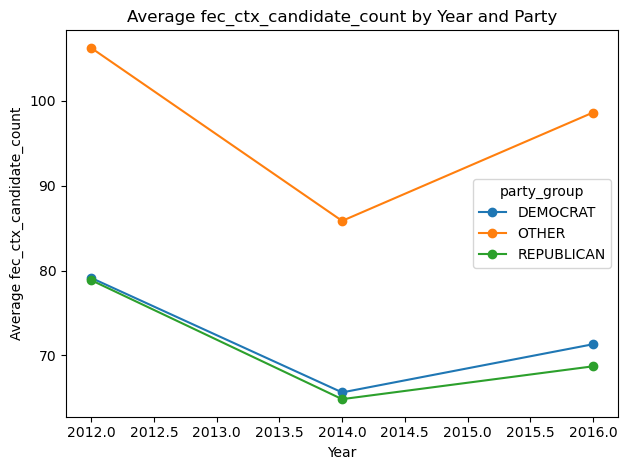

In [26]:
if MAKE_GRAPHS:
    fec_metric = None
    for candidate_metric in ["fec_log_adjusted_receipts", "fec_ctx_avg_adjusted_receipts", "fec_ctx_candidate_count"]:
        if candidate_metric in model_df.columns:
            fec_metric = candidate_metric
            break

    if fec_metric is not None:
        fec_plot_pd = (
            model_df
            .groupBy("year", "party_group")
            .agg(F.avg(fec_metric).alias(f"avg_{fec_metric}"))
            .orderBy("year", "party_group")
            .toPandas()
        )

        if len(fec_plot_pd) > 0:
            pivot_fec = fec_plot_pd.pivot(index="year", columns="party_group", values=f"avg_{fec_metric}").fillna(0)
            ax = pivot_fec.plot(kind="line", marker="o", title=f"Average {fec_metric} by Year and Party")
            ax.set_xlabel("Year")
            ax.set_ylabel(f"Average {fec_metric}")
            plt.tight_layout()
            plt.show()

    if "fec_ctx_avg_indiv_contrib_share" in model_df.columns:
        fec_share_pd = (
            model_df
            .select("party_group", "fec_ctx_avg_indiv_contrib_share")
            .sample(False, 0.25, seed=RANDOM_SEED)
            .toPandas()
        )
        if len(fec_share_pd) > 0:
            ax = fec_share_pd.boxplot(column="fec_ctx_avg_indiv_contrib_share", by="party_group")
            ax.set_title("FEC Individual Contribution Share Context by Party")
            ax.set_xlabel("Party")
            ax.set_ylabel("Context avg individual contribution share")
            plt.suptitle("")
            plt.tight_layout()
            plt.show()

In [27]:
corr_base = (
    model_df
    .withColumn("is_democrat", F.when(F.col("party_group") == "DEMOCRAT", 1.0).otherwise(0.0))
    .withColumn("is_republican", F.when(F.col("party_group") == "REPUBLICAN", 1.0).otherwise(0.0))
    .withColumn("is_other", F.when(F.col("party_group") == "OTHER", 1.0).otherwise(0.0))
)

corr_numeric_cols = [
    "total_receipts", "total_indiv_contribs", "total_pac_contribs", "num_givers",
    "recipient_cfscore", "log_total_receipts", "log_total_indiv_contribs",
    "log_total_pac_contribs", "log_num_givers",
    "ctx_year_avg_donor_cfscore", "ctx_state_avg_donor_cfscore",
    "ctx_year_left_share", "ctx_year_right_share",
    "ctx_state_left_share", "ctx_state_right_share",
]
corr_numeric_cols = [c for c in corr_numeric_cols if c in corr_base.columns]

corr_rows = []
for c in corr_numeric_cols:
    for target_col in ["is_democrat", "is_republican", "is_other"]:
        try:
            corr_val = corr_base.stat.corr(c, target_col)
            corr_rows.append((c, target_col, float(corr_val) if corr_val is not None else None))
        except Exception as e:
            corr_rows.append((c, target_col, None))

corr_df = spark.createDataFrame(corr_rows, ["feature", "target_indicator", "correlation"])
show_df(corr_df.orderBy(F.desc(F.abs(F.col("correlation")))), 100)

[Stage 183:==============================================>        (27 + 2) / 32]

+------------------------+----------------+---------------------+
|feature                 |target_indicator|correlation          |
+------------------------+----------------+---------------------+
|log_total_pac_contribs  |is_other        |-0.28969503415827347 |
|log_total_indiv_contribs|is_other        |-0.27035194676556884 |
|log_total_receipts      |is_other        |-0.2684207991707299  |
|log_num_givers          |is_other        |-0.20763827364343182 |
|log_total_indiv_contribs|is_republican   |0.17954481734462094  |
|log_total_pac_contribs  |is_republican   |0.1778689818714043   |
|log_total_receipts      |is_republican   |0.17681519722452477  |
|log_total_pac_contribs  |is_democrat     |0.14999270988475435  |
|log_total_receipts      |is_democrat     |0.12681007428001204  |
|log_num_givers          |is_democrat     |0.12652466221520464  |
|log_total_indiv_contribs|is_democrat     |0.12624553780279746  |
|log_num_givers          |is_republican   |0.10871854358438256  |
|total_pac

In [29]:
if MAKE_GRAPHS:
    # Party percentage over time
    party_year_pct_pd = party_year_pct.toPandas()
    if len(party_year_pct_pd) > 0:
        pivot_pct = party_year_pct_pd.pivot(index="year", columns="party_group", values="party_pct").fillna(0)
        ax = pivot_pct.plot(kind="line", marker="o", title="Party Percentage by Year")
        ax.set_xlabel("Year")
        ax.set_ylabel("Share of rows")
        plt.tight_layout()
        plt.show()

    # Top state party shares
    state_party_pct_pd = state_party_pct.toPandas()
    if len(state_party_pct_pd) > 0:
        top_states = state_party_pct_pd.groupby("state_group")["state_total"].max().sort_values(ascending=False).head(12).index
        state_plot = state_party_pct_pd[state_party_pct_pd["state_group"].isin(top_states)]
        pivot_state = state_plot.pivot_table(index="state_group", columns="party_group", values="party_pct", aggfunc="mean").fillna(0)
        ax = pivot_state.plot(kind="bar", stacked=True, title="Party Share by Top States")
        ax.set_xlabel("State")
        ax.set_ylabel("Share")
        plt.tight_layout()
        plt.show()

    # Donor context over time if available
    donor_cols_for_plot = [c for c in ["ctx_year_avg_donor_cfscore", "ctx_year_left_share", "ctx_year_right_share"] if c in model_df.columns]
    if donor_cols_for_plot:
        donor_year_pd = (
            model_df
            .groupBy("year")
            .agg(*[F.avg(c).alias(c) for c in donor_cols_for_plot])
            .orderBy("year")
            .toPandas()
        )
        for c in donor_cols_for_plot:
            ax = donor_year_pd.plot(kind="line", x="year", y=c, marker="o", legend=False, title=f"{c} by Year")
            ax.set_xlabel("Year")
            ax.set_ylabel(c)
            plt.tight_layout()
            plt.show()

NameError: name 'party_year_pct' is not defined

# Data Splitting, Cross-Validation, Hyperparameter Tuning, and Modeling

Model construction, evaluation, and K-fold cross-validation of hyperparameters. This section uses a held-out test set and runs cross-validation only on the training data.

## Model A

In [30]:
drop_from_features = {
    "party_raw",
    "party_group",
    "recipient_id",
    "recipient_name",
}

base_numeric_features = [
    "year",
    "recipient_cfscore",
    "primary_vote_pct",
    "general_vote_pct",
    "log_total_receipts",
    "log_total_indiv_contribs",
    "log_total_pac_contribs",
    "log_num_givers",
    "total_receipts_is_negative",
    "total_indiv_contribs_is_negative",
    "total_pac_contribs_is_negative",
]

if not USE_RECIPIENT_CFSCORE_FEATURE and "recipient_cfscore" in base_numeric_features:
    base_numeric_features.remove("recipient_cfscore")

context_numeric_features = [
    c for c in model_df.columns
    if c.startswith("fec_")
]

numeric_features = [
    c for c in base_numeric_features + context_numeric_features
    if c in model_df.columns and c not in drop_from_features
]

categorical_features = [
    c for c in [
        "recipient_type_group",
        "state_group",
        "seat_group",
        "district_group",
        "gender_group",
        "fec_incumbent_challenger",
        "fec_office_group",
        "fec_candidate_status",
    ]
    if c in model_df.columns and c not in drop_from_features
]

numeric_quality_for_model = []
for c in numeric_features:
    row = model_df.agg(
        F.approx_count_distinct(F.col(c)).alias("approx_distinct"),
        F.stddev(F.col(c)).alias("stddev")
    ).collect()[0].asDict()
    approx_distinct = int(row["approx_distinct"] or 0)
    stddev = row["stddev"]
    keep = (approx_distinct > 1) and (stddev is not None) and (float(stddev) > 0.0)
    numeric_quality_for_model.append((c, approx_distinct, float(stddev) if stddev is not None else None, keep))

numeric_model_quality_df = spark.createDataFrame(
    numeric_quality_for_model,
    ["feature", "approx_distinct", "stddev", "keep_for_model"]
)
print("Numeric model feature quality:")
show_df(numeric_model_quality_df.orderBy("keep_for_model", "feature"), 100, truncate=False)

numeric_features = [row[0] for row in numeric_quality_for_model if row[3]]

exclude_fec_numeric_features = {
    "fec_ttl_receipts", "fec_ttl_disb", "fec_trans_from_auth", "fec_trans_to_auth",
    "fec_coh_bop", "fec_coh_cop", "fec_cand_contrib", "fec_cand_loans",
    "fec_other_loans", "fec_debts_owed_by", "fec_ttl_indiv_contrib",
    "fec_other_pol_cmte_contrib", "fec_pol_pty_contrib", "fec_indiv_refunds",
    "fec_cmte_refunds", "fec_adjusted_receipts", "fec_adjusted_disb",
    "fec_sum_linked_cmte_receipts", "fec_sum_linked_cmte_disb",
    "fec_sum_linked_cmte_indv_contrib", "fec_sum_linked_cmte_other_pol_cmte_contrib",
    "fec_sum_linked_cmte_party_contrib",
}
numeric_features = [c for c in numeric_features if c not in exclude_fec_numeric_features]

print("Numeric features after zero-variance filtering:", numeric_features)
print("Categorical features:", categorical_features)

fill_numeric = {c: 0.0 for c in numeric_features}
fill_cats = {c: "MISSING" for c in categorical_features}

model_ready = (
    model_df
    .select(["party_group"] + numeric_features + categorical_features)
    .fillna(fill_numeric)
    .fillna(fill_cats)
    .filter(F.col("party_group").isNotNull())
)

train_df, test_df = model_ready.randomSplit([1.0 - TEST_FRACTION, TEST_FRACTION], seed=RANDOM_SEED)

if MAX_TRAIN_ROWS_FOR_TUNING is not None:
    train_df = train_df.limit(MAX_TRAIN_ROWS_FOR_TUNING)

train_df = train_df.repartition(MODEL_PARTITIONS).persist(StorageLevel.MEMORY_AND_DISK)
test_df = test_df.repartition(MODEL_PARTITIONS).persist(StorageLevel.MEMORY_AND_DISK)

if RUN_EXPENSIVE_COUNTS:
    print("Train rows:", train_df.count())
    print("Test rows:", test_df.count())

print("Train class balance:")
show_df(train_df.groupBy("party_group").count().orderBy(F.desc("count")), 20)

print("Test class balance:")
show_df(test_df.groupBy("party_group").count().orderBy(F.desc("count")), 20)

Numeric model feature quality:


+-------------------------------------+---------------+--------------------+--------------+
|feature                              |approx_distinct|stddev              |keep_for_model|
+-------------------------------------+---------------+--------------------+--------------+
|fec_ctx_avg_num_authorized_committees|82             |0.033400485825893785|true          |
|fec_ctx_avg_num_linked_committees    |128            |0.34861901205196144 |true          |
|fec_ctx_avg_num_principal_committees |133            |0.16609172533087346 |true          |
|fec_ctx_avg_sum_linked_cmte_receipts |166            |479247.20185598667  |true          |
|fec_ctx_candidate_count              |86             |72.67283940351632   |true          |
|log_num_givers                       |2979           |1.8025957896977427  |true          |
|log_total_indiv_contribs             |15943          |3.7690341631896915  |true          |
|log_total_pac_contribs               |9287           |3.3366041652084206  |true

Train rows: 114884
Test rows: 28358
Train class balance:
+-----------+-----+
|party_group|count|
+-----------+-----+
|OTHER      |54125|
|REPUBLICAN |30939|
|DEMOCRAT   |29820|
+-----------+-----+

Test class balance:
+-----------+-----+
|party_group|count|
+-----------+-----+
|OTHER      |13441|
|REPUBLICAN |7677 |
|DEMOCRAT   |7240 |
+-----------+-----+



## Model B

In [31]:
def add_donor_split(
    df: DataFrame,
    id_col: str,
    test_fraction: float,
    seed: int,
    split_col: str = "split",
    num_buckets: int = 1000,
) -> DataFrame:
    # Same donor always hashes to the same bucket -> always lands on the same side.
    bucket = F.pmod(F.hash(F.col(id_col), F.lit(seed)), F.lit(num_buckets))
    threshold = int(round(test_fraction * num_buckets))
    return df.withColumn(split_col, F.when(bucket < threshold, F.lit("test")).otherwise(F.lit("train")))

contrib_model_df = add_donor_split(contrib_model_df, "bonica_cid", TEST_FRACTION, RANDOM_SEED)

print("Rows by split:")
show_df(contrib_model_df.groupBy("split").count(), 5)

train_donor_count = contrib_model_df.filter(F.col("split") == "train").select("bonica_cid").distinct().count()
test_donor_count = contrib_model_df.filter(F.col("split") == "test").select("bonica_cid").distinct().count()
print("Train distinct donors:", train_donor_count, " Test distinct donors:", test_donor_count)

# Sanity check -- should always be 0 by construction, but confirm it.
overlap_count = (
    contrib_model_df.filter(F.col("split") == "train").select("bonica_cid").distinct()
    .intersect(contrib_model_df.filter(F.col("split") == "test").select("bonica_cid").distinct())
    .count()
)
print("Donor overlap between train/test (should be 0):", overlap_count)

print("Party balance by split (should be roughly similar train vs test):")
show_df(contrib_model_df.groupBy("split", "party_group").count().orderBy("split", F.desc("count")), 20)

train_only_df = contrib_model_df.filter(F.col("split") == "train")

contrib_model_df, occupation_canonical, occupation_fuzzy_map = build_bucket_with_fuzzy_match(
    fit_df=train_only_df,       # vocabulary/fuzzy-map fit on TRAIN ONLY
    apply_df=contrib_model_df,  # applied to both train and test rows
    col_name="contributor_occupation_clean",
    top_n=OCCUPATION_TOP_N,
    out_col="occupation_group",
    synonym_map=OCCUPATION_SYNONYMS,
    contains_exclude=FUZZY_CONTAINS_EXCLUDE,
)

# ---- Step 7: donor-level feature/label wiring for the ContribDB party model ----

contrib_model_df = contrib_model_df.withColumn("log_amount", F.log1p(F.col("amount")))

CONTRIB_TRAIN_PARQUET = PROCESSED_DIR / f"contrib_donor_party_train_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
CONTRIB_TEST_PARQUET = PROCESSED_DIR / f"contrib_donor_party_test_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"

def materialize_split(df: DataFrame, out_path: Path, force: bool = False) -> DataFrame:
    if not force and parquet_has_data(out_path):
        return spark.read.parquet(str(out_path))
    df.repartition(MODEL_PARTITIONS).write.mode("overwrite").option("compression", "snappy").parquet(str(out_path))
    return spark.read.parquet(str(out_path))

contrib_train_df = materialize_split(contrib_model_df.filter(F.col("split") == "train"), CONTRIB_TRAIN_PARQUET)
contrib_test_df = materialize_split(contrib_model_df.filter(F.col("split") == "test"), CONTRIB_TEST_PARQUET)

print("Contrib train rows:", contrib_train_df.count(), " Contrib test rows:", contrib_test_df.count())

# ---- Label: fit on TRAIN ONLY, apply to both ----
contrib_label_indexer = StringIndexer(inputCol="party_group", outputCol="label", handleInvalid="skip").fit(contrib_train_df)
contrib_train_df = contrib_label_indexer.transform(contrib_train_df)
contrib_test_df = contrib_label_indexer.transform(contrib_test_df)

print("Contrib label mapping:", list(enumerate(contrib_label_indexer.labels)))

# ---- Namespaced feature lists ----
contrib_numeric_features = ["log_amount"]
contrib_categorical_features = [
    "occupation_group",
    "transaction_type",
    "seat_group",
    "contributor_state",
    "recipient_state_group",
    "election_type_group",
    "contributor_gender",
    "contributor_type",
]

print("Contrib numeric features:", contrib_numeric_features)
print("Contrib categorical features:", contrib_categorical_features)


Rows by split:


+-----+-------+
|split|count  |
+-----+-------+
|train|1655746|
|test |416264 |
+-----+-------+



Train distinct donors: 938619  Test distinct donors: 234929


Donor overlap between train/test (should be 0): 0
Party balance by split (should be roughly similar train vs test):


/apps/software/standard/core/pyspark/4.0.0-py3.11/lib/python3.11/site-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


+-----+-----------+-------+
|split|party_group|count  |
+-----+-----------+-------+
|test |DEMOCRAT   |282087 |
|test |REPUBLICAN |106185 |
|test |OTHER      |27992  |
|train|DEMOCRAT   |1122024|
|train|REPUBLICAN |421454 |
|train|OTHER      |112268 |
+-----+-----------+-------+



Fuzzy map rows: 52543
Contrib train rows: 1655746  Contrib test rows: 416264
Contrib label mapping: [(0, 'DEMOCRAT'), (1, 'REPUBLICAN'), (2, 'OTHER')]
Contrib numeric features: ['log_amount']
Contrib categorical features: ['occupation_group', 'transaction_type', 'seat_group', 'contributor_state', 'recipient_state_group', 'election_type_group', 'contributor_gender', 'contributor_type']


## Initialize Cross Validation Evalutation

In [36]:
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_weighted_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_weighted_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

# Cross-validation optimizes weighted F1.
cv_evaluator = evaluator_f1

def build_preprocess_stages(numeric_cols, categorical_cols, output_features_col="features", scale_numeric=True):
    label_indexer = StringIndexer(inputCol="party_group", outputCol="label", handleInvalid="skip")

    cat_indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in categorical_cols
    ]

    encoder = OneHotEncoder(
        inputCols=[f"{c}_idx" for c in categorical_cols],
        outputCols=[f"{c}_ohe" for c in categorical_cols],
        handleInvalid="keep"
    )

    assembler_inputs = numeric_cols + [f"{c}_ohe" for c in categorical_cols]

    assembler = VectorAssembler(
        inputCols=assembler_inputs,
        outputCol="features_raw",
        handleInvalid="keep"
    )

    stages = [label_indexer] + cat_indexers + [encoder, assembler]

    if scale_numeric:
        scaler = StandardScaler(
            inputCol="features_raw",
            outputCol=output_features_col,
            withMean=False,
            withStd=True
        )
        stages.append(scaler)

    return stages

def get_label_names_from_pipeline_model(model):
    for st in model.stages:
        if hasattr(st, "labels"):
            return list(st.labels)
    return []

def compute_multiclass_ovr_auc(pred_df, labels):
    if "probability" not in pred_df.columns:
        return {"macro_ovr_auc": None, "weighted_ovr_auc": None}

    label_counts = {
        row["label"]: row["count"]
        for row in pred_df.groupBy("label").count().collect()
    }
    total = sum(label_counts.values())
    if total == 0:
        return {"macro_ovr_auc": None, "weighted_ovr_auc": None}

    prob_df = pred_df.withColumn("prob_array", vector_to_array(F.col("probability")))

    binary_eval = BinaryClassificationEvaluator(
        labelCol="binary_label",
        rawPredictionCol="score",
        metricName="areaUnderROC"
    )

    aucs = []
    weighted_parts = []

    for i, label_name in enumerate(labels):
        tmp = (
            prob_df
            .select(
                F.when(F.col("label") == float(i), 1.0).otherwise(0.0).alias("binary_label"),
                F.col("prob_array")[i].alias("score")
            )
            .filter(F.col("score").isNotNull())
        )

        pos_neg = tmp.groupBy("binary_label").count().collect()
        if len(pos_neg) < 2:
            auc = None
        else:
            auc = binary_eval.evaluate(tmp)

        if auc is not None:
            aucs.append(float(auc))
            weighted_parts.append(float(auc) * (label_counts.get(float(i), 0) / total))

    return {
        "macro_ovr_auc": sum(aucs) / len(aucs) if aucs else None,
        "weighted_ovr_auc": sum(weighted_parts) if weighted_parts else None,
    }

def evaluate_predictions(pred_df, model_name, labels):
    metrics = {
        "model": model_name,
        "accuracy": evaluator_acc.evaluate(pred_df),
        "weighted_f1": evaluator_f1.evaluate(pred_df),
        "weighted_precision": evaluator_weighted_precision.evaluate(pred_df),
        "weighted_recall": evaluator_weighted_recall.evaluate(pred_df),
    }

    try:
        metrics.update(compute_multiclass_ovr_auc(pred_df, labels))
    except Exception as e:
        print(f"AUROC could not be computed for {model_name}: {e}")
        metrics["macro_ovr_auc"] = None
        metrics["weighted_ovr_auc"] = None

    return metrics

def confusion_table(pred_df, labels):
    mapping = spark.createDataFrame(
        [(float(i), label) for i, label in enumerate(labels)],
        ["label_index", "label_name"]
    )

    pred_mapping = spark.createDataFrame(
        [(float(i), label) for i, label in enumerate(labels)],
        ["prediction_index", "prediction_name"]
    )

    return (
        pred_df
        .groupBy("label", "prediction")
        .count()
        .join(mapping, F.col("label") == F.col("label_index"), "left")
        .join(pred_mapping, F.col("prediction") == F.col("prediction_index"), "left")
        .select("label_name", "prediction_name", "count")
        .orderBy("label_name", "prediction_name")
    )

def cv_results_table(cv_model, param_names, model_name):
    rows = []
    for param_map, metric in zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics):
        row = {"model": model_name, "cv_weighted_f1": float(metric)}
        for param_obj, display_name in param_names:
            row[display_name] = str(param_map.get(param_obj, None))
        rows.append(row)

    if not rows:
        rows = [{"model": model_name, "cv_weighted_f1": None}]

    return spark.createDataFrame(pd.DataFrame(rows))

In [37]:
def get_stage_by_type(pipeline_model, type_name: str):
    for st in pipeline_model.stages:
        if st.__class__.__name__ == type_name:
            return st
    return None

def get_stages_by_type(pipeline_model, type_name: str):
    return [st for st in pipeline_model.stages if st.__class__.__name__ == type_name]

def build_feature_names_from_pipeline_model(pipeline_model, numeric_cols, categorical_cols):
    """
    Reconstructs the feature vector names after:
    StringIndexer -> OneHotEncoder -> VectorAssembler.

    Numeric features appear first. Then OHE categorical levels are expanded.
    """
    feature_names = list(numeric_cols)

    # StringIndexerModels have inputCol and labels.
    indexer_models = {
        st.getInputCol(): list(st.labels)
        for st in pipeline_model.stages
        if st.__class__.__name__ == "StringIndexerModel" and st.getInputCol() in categorical_cols
    }

    # OHE usually drops the last category by default. If dropLast=True, vector size is len(labels)-1.
    encoder_model = get_stage_by_type(pipeline_model, "OneHotEncoderModel")
    drop_last = True
    category_sizes = None
    if encoder_model is not None:
        try:
            drop_last = encoder_model.getDropLast()
        except Exception:
            drop_last = True
        try:
            category_sizes = list(encoder_model.categorySizes)
        except Exception:
            category_sizes = None

    for idx, c in enumerate(categorical_cols):
        labels = indexer_models.get(c, [])
        if category_sizes is not None and idx < len(category_sizes):
            size = int(category_sizes[idx])
        else:
            size = max(len(labels) - 1, 1) if drop_last else len(labels)

        for j in range(size):
            if j < len(labels):
                feature_names.append(f"{c}={labels[j]}")
            else:
                feature_names.append(f"{c}=__unknown_{j}")

    return feature_names

def random_forest_feature_importance_df(cv_model, numeric_cols, categorical_cols, model_name="Random Forest"):
    best_pipeline = cv_model.bestModel
    rf_model = best_pipeline.stages[-1]

    feature_names = build_feature_names_from_pipeline_model(best_pipeline, numeric_cols, categorical_cols)
    importances = rf_model.featureImportances.toArray().tolist()

    # Align lengths safely.
    n = min(len(feature_names), len(importances))
    rows = [(model_name, feature_names[i], float(importances[i])) for i in range(n)]

    # Add unnamed features if Spark vector is longer than reconstructed names.
    if len(importances) > len(feature_names):
        for i in range(len(feature_names), len(importances)):
            rows.append((model_name, f"feature_{i}", float(importances[i])))

    return spark.createDataFrame(rows, ["model", "feature", "importance"]).orderBy(F.desc("importance"))

def logistic_coefficient_importance_df(cv_model, numeric_cols, categorical_cols, model_name="Logistic Regression"):
    """
    For multinomial logistic regression, coefficientMatrix is classes x features.
    We summarize feature importance as the mean absolute coefficient across classes.
    """
    best_pipeline = cv_model.bestModel
    lr_model = best_pipeline.stages[-1]

    feature_names = build_feature_names_from_pipeline_model(best_pipeline, numeric_cols, categorical_cols)
    coef_matrix = lr_model.coefficientMatrix.toArray()

    mean_abs = abs(coef_matrix).mean(axis=0).tolist()

    n = min(len(feature_names), len(mean_abs))
    rows = [(model_name, feature_names[i], float(mean_abs[i])) for i in range(n)]

    if len(mean_abs) > len(feature_names):
        for i in range(len(feature_names), len(mean_abs)):
            rows.append((model_name, f"feature_{i}", float(mean_abs[i])))

    return spark.createDataFrame(rows, ["model", "feature", "mean_abs_coefficient"]).orderBy(F.desc("mean_abs_coefficient"))

def group_ohe_importance(importance_df: DataFrame, value_col: str):
    """
    Groups one-hot encoded feature levels back to the original feature name.
    Example: state_group=CA, state_group=NY -> state_group.
    """
    grouped = (
        importance_df
        .withColumn(
            "feature_group",
            F.when(F.col("feature").contains("="), F.split(F.col("feature"), "=").getItem(0))
             .otherwise(F.col("feature"))
        )
        .groupBy("model", "feature_group")
        .agg(F.sum(F.col(value_col)).alias(f"grouped_{value_col}"))
        .orderBy(F.desc(f"grouped_{value_col}"))
    )
    return grouped

# Model 1: Benchmark Logistic Regression with CV

## Model A:

In [38]:
benchmark_numeric = [c for c in ["log_total_receipts", "log_num_givers", "year"] if c in numeric_features]
benchmark_categorical = [c for c in ["seat_group"] if c in categorical_features]

benchmark_preprocess = build_preprocess_stages(
    benchmark_numeric,
    benchmark_categorical,
    output_features_col="features",
    scale_numeric=True
)

benchmark_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    family="multinomial",
    maxIter=30
)

benchmark_pipeline = Pipeline(stages=benchmark_preprocess + [benchmark_lr])

if FAST_CV:
    benchmark_grid = (
        ParamGridBuilder()
        .addGrid(benchmark_lr.regParam, [0.0, 0.05])
        .addGrid(benchmark_lr.elasticNetParam, [0.0])
        .build()
    )
else:
    benchmark_grid = (
        ParamGridBuilder()
        .addGrid(benchmark_lr.regParam, [0.0, 0.01, 0.05, 0.1])
        .addGrid(benchmark_lr.elasticNetParam, [0.0, 0.5])
        .build()
    )

benchmark_cv = CrossValidator(
    estimator=benchmark_pipeline,
    estimatorParamMaps=benchmark_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 4)),
    seed=RANDOM_SEED
)

benchmark_cv_model = benchmark_cv.fit(train_df)
benchmark_pred = benchmark_cv_model.transform(test_df)
benchmark_labels = get_label_names_from_pipeline_model(benchmark_cv_model.bestModel)

benchmark_metrics = evaluate_predictions(benchmark_pred, "Benchmark Logistic Regression", benchmark_labels)
benchmark_metrics

{'model': 'Benchmark Logistic Regression',
 'accuracy': 0.6197545666125961,
 'weighted_f1': 0.5798694981639755,
 'weighted_precision': 0.5871992898140215,
 'weighted_recall': 0.6197545666125961,
 'macro_ovr_auc': 0.7796591540890673,
 'weighted_ovr_auc': 0.7979659643727215}

In [39]:
# Benchmark CV sensitivity table and confusion matrix
benchmark_cv_table = cv_results_table(
    benchmark_cv_model,
    [(benchmark_lr.regParam, "regParam"), (benchmark_lr.elasticNetParam, "elasticNetParam")],
    "Benchmark Logistic Regression"
).orderBy(F.desc("cv_weighted_f1"))

show_df(benchmark_cv_table, 50)
show_df(confusion_table(benchmark_pred, benchmark_labels), 100)

+-----------------------------+------------------+--------+---------------+
|model                        |cv_weighted_f1    |regParam|elasticNetParam|
+-----------------------------+------------------+--------+---------------+
|Benchmark Logistic Regression|0.574849166805981 |0.0     |0.0            |
|Benchmark Logistic Regression|0.5686129348945048|0.05    |0.0            |
+-----------------------------+------------------+--------+---------------+



[Stage 1688:(29 + 2) / 32][Stage 1690:>(0 + 0) / 16][Stage 1692:> (0 + 0) / 1]6]

+----------+---------------+-----+
|label_name|prediction_name|count|
+----------+---------------+-----+
|DEMOCRAT  |DEMOCRAT       |1256 |
|DEMOCRAT  |OTHER          |2486 |
|DEMOCRAT  |REPUBLICAN     |3498 |
|OTHER     |DEMOCRAT       |207  |
|OTHER     |OTHER          |12286|
|OTHER     |REPUBLICAN     |948  |
|REPUBLICAN|DEMOCRAT       |1209 |
|REPUBLICAN|OTHER          |2435 |
|REPUBLICAN|REPUBLICAN     |4033 |
+----------+---------------+-----+



## Model B

In [40]:
benchmark_numeric = [c for c in ["log_amount"] if c in numeric_features]
benchmark_categorical = [c for c in ["seat_group"] if c in categorical_features]

benchmark_preprocess = build_preprocess_stages(
    benchmark_numeric,
    benchmark_categorical,
    output_features_col="features",
    scale_numeric=True
)

benchmark_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    family="multinomial",
    maxIter=30
)

benchmark_pipeline = Pipeline(stages=benchmark_preprocess + [benchmark_lr])

if FAST_CV:
    benchmark_grid = (
        ParamGridBuilder()
        .addGrid(benchmark_lr.regParam, [0.0, 0.05])
        .addGrid(benchmark_lr.elasticNetParam, [0.0])
        .build()
    )
else:
    benchmark_grid = (
        ParamGridBuilder()
        .addGrid(benchmark_lr.regParam, [0.0, 0.01, 0.05, 0.1])
        .addGrid(benchmark_lr.elasticNetParam, [0.0, 0.5])
        .build()
    )

benchmark_cv = CrossValidator(
    estimator=benchmark_pipeline,
    estimatorParamMaps=benchmark_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 4)),
    seed=RANDOM_SEED
)

benchmark_cv_model = benchmark_cv.fit(train_df)
benchmark_pred = benchmark_cv_model.transform(test_df)
benchmark_labels = get_label_names_from_pipeline_model(benchmark_cv_model.bestModel)

benchmark_metrics = evaluate_predictions(benchmark_pred, "Benchmark Logistic Regression", benchmark_labels)
benchmark_metrics

{'model': 'Benchmark Logistic Regression',
 'accuracy': 0.6179561323083433,
 'weighted_f1': 0.532641575568538,
 'weighted_precision': 0.5662303950417756,
 'weighted_recall': 0.6179561323083432,
 'macro_ovr_auc': 0.775911678198061,
 'weighted_ovr_auc': 0.793983413524846}

# Model 2: Full Multinomial Logistic Regression with CV

In [ ]:
full_lr_preprocess = build_preprocess_stages(
    numeric_features,
    categorical_features,
    output_features_col="features",
    scale_numeric=True
)

full_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    family="multinomial",
    maxIter=60
)

full_lr_pipeline = Pipeline(stages=full_lr_preprocess + [full_lr])

if FAST_CV:
    full_lr_grid = (
        ParamGridBuilder()
        .addGrid(full_lr.regParam, [0.01, 0.05])
        .addGrid(full_lr.elasticNetParam, [0.0, 0.5])
        .build()
    )
else:
    full_lr_grid = (
        ParamGridBuilder()
        .addGrid(full_lr.regParam, [0.001, 0.01, 0.05, 0.1])
        .addGrid(full_lr.elasticNetParam, [0.0, 0.25, 0.5, 1.0])
        .build()
    )

full_lr_cv = CrossValidator(
    estimator=full_lr_pipeline,
    estimatorParamMaps=full_lr_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 4)),
    seed=RANDOM_SEED
)

full_lr_cv_model = full_lr_cv.fit(train_df)
full_lr_pred = full_lr_cv_model.transform(test_df)
full_lr_labels = get_label_names_from_pipeline_model(full_lr_cv_model.bestModel)

full_lr_metrics = evaluate_predictions(full_lr_pred, "Full Multinomial Logistic Regression", full_lr_labels)
full_lr_metrics

In [ ]:
full_lr_cv_table = cv_results_table(
    full_lr_cv_model,
    [(full_lr.regParam, "regParam"), (full_lr.elasticNetParam, "elasticNetParam")],
    "Full Multinomial Logistic Regression"
).orderBy(F.desc("cv_weighted_f1"))

show_df(full_lr_cv_table, 100)
show_df(confusion_table(full_lr_pred, full_lr_labels), 100)

# Model 3: Random Forest with CV

In [ ]:
rf_preprocess = build_preprocess_stages(
    numeric_features,
    categorical_features,
    output_features_col="features",
    scale_numeric=False
)

rf = RandomForestClassifier(
    featuresCol="features_raw",
    labelCol="label",
    seed=RANDOM_SEED
)

rf_pipeline = Pipeline(stages=rf_preprocess + [rf])

if FAST_CV:
    rf_grid = (
        ParamGridBuilder()
        .addGrid(rf.numTrees, [50])
        .addGrid(rf.maxDepth, [5])
        .addGrid(rf.featureSubsetStrategy, ["sqrt"])
        .build()
    )
else:
    rf_grid = (
        ParamGridBuilder()
        .addGrid(rf.numTrees, [50, 100, 150])
        .addGrid(rf.maxDepth, [5, 8, 12])
        .addGrid(rf.featureSubsetStrategy, ["sqrt", "log2"])
        .build()
    )

rf_cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 5)),
    seed=RANDOM_SEED
)

rf_cv_model = rf_cv.fit(train_df)
rf_pred = rf_cv_model.transform(test_df)
rf_labels = get_label_names_from_pipeline_model(rf_cv_model.bestModel)

rf_metrics = evaluate_predictions(rf_pred, "Random Forest", rf_labels)
rf_metrics

In [ ]:
rf_cv_table = cv_results_table(
    rf_cv_model,
    [(rf.numTrees, "numTrees"), (rf.maxDepth, "maxDepth"), (rf.featureSubsetStrategy, "featureSubsetStrategy")],
    "Random Forest"
).orderBy(F.desc("cv_weighted_f1"))

show_df(rf_cv_table, 100)
show_df(confusion_table(rf_pred, rf_labels), 100)

# Model Importance

This section adds interpretability outputs:

1. **Random Forest feature importance** from the tuned champion candidate.
2. **Grouped Random Forest importance**, where one-hot encoded levels are grouped back to the original column.
3. **Logistic Regression coefficient importance**, based on mean absolute coefficients across party classes.

In [ ]:
# Random Forest feature importance

rf_importance_df = random_forest_feature_importance_df(
    rf_cv_model,
    numeric_features,
    categorical_features,
    model_name="Random Forest"
)

print("Top Random Forest feature importances:")
show_df(rf_importance_df, 50, truncate=False)

rf_grouped_importance_df = group_ohe_importance(rf_importance_df, "importance")

print("Grouped Random Forest feature importances:")
show_df(rf_grouped_importance_df, 50, truncate=False)

if MAKE_GRAPHS:
    rf_imp_pd = rf_grouped_importance_df.limit(20).toPandas()
    if len(rf_imp_pd) > 0:
        ax = rf_imp_pd.sort_values("grouped_importance").plot(
            kind="barh",
            x="feature_group",
            y="grouped_importance",
            legend=False,
            title="Top Grouped Random Forest Feature Importances"
        )
        ax.set_xlabel("Grouped importance")
        ax.set_ylabel("Feature group")
        plt.tight_layout()
        plt.show()

In [ ]:
# Logistic Regression coefficient importance

full_lr_coef_importance_df = logistic_coefficient_importance_df(
    full_lr_cv_model,
    numeric_features,
    categorical_features,
    model_name="Full Multinomial Logistic Regression"
)

print("Top Logistic Regression coefficient importances:")
show_df(full_lr_coef_importance_df, 50, truncate=False)

full_lr_grouped_coef_importance_df = group_ohe_importance(
    full_lr_coef_importance_df.withColumnRenamed("mean_abs_coefficient", "coef_importance"),
    "coef_importance"
)

print("Grouped Logistic Regression coefficient importances:")
show_df(full_lr_grouped_coef_importance_df, 50, truncate=False)

if MAKE_GRAPHS:
    lr_imp_pd = full_lr_grouped_coef_importance_df.limit(20).toPandas()
    if len(lr_imp_pd) > 0:
        ax = lr_imp_pd.sort_values("grouped_coef_importance").plot(
            kind="barh",
            x="feature_group",
            y="grouped_coef_importance",
            legend=False,
            title="Top Grouped Logistic Regression Coefficient Importances"
        )
        ax.set_xlabel("Grouped mean absolute coefficient")
        ax.set_ylabel("Feature group")
        plt.tight_layout()
        plt.show()

In [ ]:
# 18. Model comparison and champion selection

metrics_rows = [benchmark_metrics, full_lr_metrics, rf_metrics]
metrics_pdf = pd.DataFrame(metrics_rows)

model_comparison = spark.createDataFrame(metrics_pdf).orderBy(F.desc("weighted_f1"))

show_df(model_comparison, 20)

champion_row = model_comparison.first().asDict()
champion_model_name = champion_row["model"]

print("Champion model:", champion_model_name)
print("Champion weighted F1:", champion_row["weighted_f1"])
print("Champion weighted AUROC:", champion_row.get("weighted_ovr_auc"))

# Save final outputs

In [ ]:
MODEL_OUTPUT_DIR = PROCESSED_DIR / f"final_project_outputs_{YEAR_LABEL}"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_comparison.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "model_comparison_parquet"))
benchmark_cv_table.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "benchmark_cv_results_parquet"))
full_lr_cv_table.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "full_lr_cv_results_parquet"))
rf_cv_table.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "rf_cv_results_parquet"))

# Save model importance outputs
rf_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "rf_feature_importance_parquet"))
rf_grouped_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "rf_grouped_feature_importance_parquet"))
full_lr_coef_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "full_lr_coefficient_importance_parquet"))
full_lr_grouped_coef_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "full_lr_grouped_coefficient_importance_parquet"))

class_balance.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "class_balance_parquet"))
eda_year_party.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "eda_year_party_parquet"))
eda_state_party.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "eda_state_party_parquet"))
eda_seat_party.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "eda_seat_party_parquet"))

print("Saved outputs to:", MODEL_OUTPUT_DIR)